# Paper combined - train the edit model, then run BCO experiments

**PART 1** trains the edit agent FROM SCRATCH on the 700-graph graded realistic curriculum (dup -> stub -> detour -> drop_cover -> subtle -> eval-mix -> clean) with the unified objective: 0.5*RTT + 0.5*WMC and a network-level adjustment budget (cap at target=0.2, W=10, paper mode, demand off; the BCO search uses the two-sided |adj-target| form). **PART 2** runs the paper experiments (E1-E6) using that fine-tuned model as `OUR_MODEL_PATH`. Algorithm budgets are set for a full top-to-bottom run that should fit into roughly 25-30 hours on the current CPU calibration; rerun the timing estimator cell after any budget change.

Run top-to-bottom: training must finish before the experiment config picks up the trained weights.


In [1]:
import torch

torch.__version__

'2.11.0+cpu'

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # select GPU 1
import sys, pickle, shutil, json, random as _random
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from hydra import compose, initialize_config_dir
from tqdm.auto import tqdm
from IPython.display import Image, display

from eval_lib.context import (ROOT_DIR, CFG_DIR, DATASETS_DIR,
                              MODEL_OUTPUTS_DIR, EDIT_MODEL_WEIGHTS_DIR)
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.improvement_learning import (
    _get_planned_current_routes, _make_route_context_state,
    load_raw_graphs_and_lc_routes, make_improvement_batch,
    rollout_lc_improvement, train_lc_improvement_cfg)
from connectpt.routes_generator.torch_utils import (
    get_batch_tensor_from_routes, dump_routes)
from connectpt.routes_generator.transit_time_estimator import (
    ROUTE_ACTION_EXTEND, ROUTE_ACTION_HALT, ROUTE_ACTION_TRIM_END,
    ROUTE_ACTION_TRIM_START, RouteGenBatchState)
from connectpt.routes_generator.citygraph_dataset import (
    STOP_KEY, DynamicCityGraphDataset)
from connectpt.routes_generator.bee_colony import get_adjustment_degrees
from torch_geometric.data import Batch
from eval_lib.results_io import save_table
from eval_lib import build_lc_cfg, run_lc, as_route_tensor
from eval_lib import plots as route_plots

pd.set_option("display.max_columns", None)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [ ]:
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

from eval_lib.context import ROOT_DIR, EDIT_MODEL_WEIGHTS_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from eval_lib import *                      # runners, builders, BENCHMARK_SPECS, ...
from eval_lib import _run_baseline          # private: not pulled by `import *`
from eval_lib import plots as route_plots
from connectpt.routes_generator.bee_colony import get_adjustment_degrees

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_columns", None)
print("device:", device)

# --- wall-clock instrumentation (per-epoch / per-iteration) ---
import time as _time
TIMING = {"epoch_s": None, "dataset_graph_s": None, "bco_iter_s": {}, "base_iter_s": {}}

# --- experiment-suite profile: ONE source of truth = cfg/experiments/suite*.yaml ---
# 'suite_smoke' = every experiment ON, single city, 1-iteration specs, TEMP_ outputs
# (a dry-run that never overwrites real files); 'suite' = the full paper run.
from eval_lib.suite import load_suite_config
from eval_lib.paper import set_paper_prefix
SUITE = load_suite_config("suite_smoke")
set_paper_prefix(SUITE.output_prefix)
print(f"suite profile={SUITE.profile} smoke={SUITE.smoke} prefix={SUITE.output_prefix!r} "
      f"cities={list(SUITE.cities)}")


## Configuration

`copy_full`, `copy_boundary`, `copy_mixed`, and `lc_clean` are equal-size
tiers.  The three corrupted tiers are generated from LC routes with the four
copy/subcopy mutations below.  Multiplicity grows across the curriculum up to
five routes on one stop-to-stop leg.

In [ ]:
# --- training configuration: cfg/train/edit_scratch[_smoke].yaml, selected by the
# suite profile loaded above (smoke -> tiny dataset, 1 iteration, TEMP_ outputs). ---
from experiments.training_lc import load_train_config
train_cfg = load_train_config("edit_scratch_smoke" if SUITE.smoke else "edit_scratch")
print(f"train cfg: run={train_cfg.run.name}, n_iterations={train_cfg.train_loop.n_iterations}, "
      f"dataset={train_cfg.data.dataset_dirname}, tiers={list(train_cfg.curriculum.tiers)}")

# Objective constants used by the LIVE experiment-setup cells (benchmark loader,
# EKB). Sourced from eval_lib.params, which reads cfg/objective/rtt_wmc_no_demand.yaml
# -- params IS the config reader, so these are not notebook-defined values.
from eval_lib.params import (CONNECTIVITY_MODE, DISABLED_COST_COMPONENTS,
                             UNIFIED_COST_WEIGHTS, ADJ_WEIGHT, ADJ_TARGET,
                             ADJ_GAP, ADJ_MODE)


## Generate the four-tier route-copy dataset

Every corruption copies a whole donor route or a contiguous donor subroute
into another route slot.  Prefix, suffix, and interior replacements preserve
the recipient length.  Candidates with repeated stops are rejected, so the
dataset teaches inter-route redundancy rather than synthetic self-loops.

In [ ]:
if SUITE.run.training:
    # Dataset generation: build the copy-tier dataset straight from the cfg
    # (experiments.training_lc.copytier_config reads cfg.dataset_gen / data /
    # curriculum; no N_GRAPHS / RAW_* / LC_COMBOS constants in the notebook).
    from experiments.training_lc import copytier_config, build_copytier_dataset

    _sec = build_copytier_dataset(copytier_config(train_cfg))
    if _sec is not None:
        TIMING["dataset_graph_s"] = _sec
        print(f"[timing] dataset gen: {_sec:.2f} s/graph "
              f"(N_GRAPHS={train_cfg.dataset_gen.n_graphs})")


## Load, split, and define the cumulative curriculum

In [ ]:
if SUITE.run.training:
    # Load graphs + the tier-stratified split for the dormant report cells.
    # Geometry/paths come from copytier_config(train_cfg); the split reproduces
    # TrainingDataModule.stratified_split (same logic EditTrainingRun uses).
    from connectpt.routes_generator.training import TrainingDataModule
    from experiments.training_lc import copytier_config

    _ct = copytier_config(train_cfg)
    _dm = TrainingDataModule(
        raw_graphs_path=_ct.subset_pkl, lc_results_dir=_ct.new_dataset_dir, device=device,
        min_route_len=_ct.min_route_len, max_route_len=_ct.max_route_len,
        target_n_routes=_ct.target_n_routes).setup()
    graphs, seed_routes = _dm.graphs, _dm.seed_routes
    meta_df = pd.read_csv(_ct.meta_csv)
    print(f"loaded {len(graphs)} graphs; seed_routes={tuple(seed_routes.shape)}")
    display(meta_df.groupby("tier")[[
        "applied_events", "redun_before", "redun_after",
        "max_leg_use_after", "d_un_after_pct"]].mean().round(3).reindex(_ct.tiers))

    _tier_of = dict(zip(meta_df["graph_index"], meta_df["tier"]))
    (TRAIN_INDICES, VAL_INDICES, MONITOR_VAL_INDICES,
     _train_by_tier, _val_by_tier) = _dm.stratified_split(
        _tier_of, _ct.tiers, train_fraction=float(train_cfg.data.train_fraction),
        n_val_per_tier=int(train_cfg.curriculum.n_val_per_tier),
        seed=int(train_cfg.data.split_seed))
    print(f"validation graphs={len(VAL_INDICES)}; monitor={len(MONITOR_VAL_INDICES)}")

    # curriculum stage spans (start,end,label) for the history-figure shading
    _n_iter = int(train_cfg.train_loop.n_iterations)
    _schedule = [(round(float(f) * _n_iter), list(t), lab)
                 for f, t, lab in train_cfg.curriculum.schedule]

    def stage_spans():
        spans, prev = [], 0
        for until, _t, label in _schedule:
            spans.append((prev + 1, until, label)); prev = until
        return spans


## Model and objective builders

Two helpers used by the fine-tune run below. `build_edit_run` composes the
hydra config, builds a **fresh** trim model + cost module, selects which of
the three cost components (`demand` / `route` / `connectivity`) are active,
and enables the optional adjustment-degree shaping through `adj_weight`.
`train_edit_run` wraps `train_lc_improvement_cfg` and returns the in-memory
history. Adjustment conditioning stays off, so the fine-tuned actor keeps the
same architecture as the RTT+connectivity checkpoint.


In [7]:
# Config-first model/cost builder for the dormant standalone balanced-eval cell.
# There is no bespoke "build_edit_run" anymore -- the real training runs via
# EditTrainingRun (cell 15). This re-exports the library helpers that build the
# edit model + unified cost config-first from train/edit + the objective YAML;
# the old 60-line builder (with vestigial adj_*/critic params it never used) and
# the rollout-kwargs helper now live in experiments/training_lc.py.
from experiments.training_lc import build_edit_model_and_cost, rollout_adjustment_kwargs

print("builders ready: build_edit_model_and_cost(), rollout_adjustment_kwargs() "
      "[config-first via experiments.training_lc]")


builders ready: build_edit_model_and_cost(), rollout_adjustment_kwargs() [config-first via experiments.training_lc]


## Clean LC baseline costs for history plots

Generate clean LC routes for the validation monitor graphs, score them with the same route/connectivity scalar used by the training-history plots, and save the result as a standalone CSV baseline.


In [ ]:
# Clean-LC baseline for the training-history figure. Knobs live in
# cfg.report.baseline; heavy logic in experiments.training_lc.clean_lc_baseline.
if SUITE.run.clean_lc_baseline:
    from experiments.training_lc import clean_lc_baseline, copytier_config
    _ct = copytier_config(train_cfg)
    if "graphs" not in globals() or "seed_routes" not in globals():
        graphs, seed_routes = load_raw_graphs_and_lc_routes(_ct.subset_pkl, _ct.new_dataset_dir)
    if "meta_df" not in globals():
        meta_df = pd.read_csv(_ct.meta_csv)
    clean_lc_baseline_df = clean_lc_baseline(
        train_cfg, graphs=graphs, seed_routes=seed_routes, meta_df=meta_df, device=device,
        baseline_path=MODEL_OUTPUTS_DIR / f"{train_cfg.run.name}_clean_lc_baseline_cost.csv")
    display(clean_lc_baseline_df.round(4))


## From-scratch training - route + connectivity + adj (W=10)

This run starts from the final-experiments RTT + connectivity checkpoint,
keeps `route` and `connectivity` active at 0.5/0.5 (demand off), and adds
network-level adjustment-budget reward shaping (cap at target=0.2, W=10, paper mode). The budget is 100
epochs over the current 500-graph copy-redundancy curriculum, batch 4, with
balanced per-tier validation monitoring. The resulting checkpoint is saved
under a new `adjcap` run name and is used by the evaluation cells below.

If `RESUME_FROM_CHECKPOINT=True`, this cell reloads the adj-finetune output
first; otherwise it initializes from `BASE_MODEL_PATH`.


In [ ]:
if SUITE.run.training:
    # Config-first training: EditTrainingRun builds model + cost + curriculum +
    # data from train_cfg (cfg/train/edit_scratch.yaml) and trains it.
    from pathlib import Path
    from connectpt.routes_generator.training import EditTrainingRun

    _artifact = EditTrainingRun(train_cfg).run()
    history_df = _artifact.history
    BEST_MODEL_PATH = Path(_artifact.checkpoint_path)
    print(f"training done -> {BEST_MODEL_PATH} ({len(history_df)} epochs)")


## Train the edit model (cumulative curriculum)

Fine-tune the edit model over the cumulative curriculum (duplicate -> boundary
-> mixed -> covered -> clean). Training history is checkpointed to a partial CSV;
on resume the prior history is prepended.

In [ ]:
if SUITE.run.training:
    # History stitching + actor curves + TensorBoard mirroring (cfg-driven:
    # run name + scalar allow-list come from train_cfg.report).
    from experiments.training_lc import stitch_history, plot_training_history

    h, _spans = stitch_history(
        prior_history_files=(),
        history_df=globals().get("history_df"),
        full_history_checkpoint=MODEL_OUTPUTS_DIR / f"{train_cfg.run.name}_training_history_partial.csv")
    if not _spans and "stage_spans" in globals():
        _spans = stage_spans()
    _shade = plot_training_history(h, _spans, train_cfg, model_outputs_dir=MODEL_OUTPUTS_DIR)
    print(f'[tensorboard] launch:  tensorboard --logdir "{MODEL_OUTPUTS_DIR / "tensorboard"}"')


## Critic diagnostics (per-component critic MSE / explained variance)

In [ ]:
if SUITE.run.training:
    from experiments.training_lc import plot_critic_metrics
    _crit_tbl = plot_critic_metrics(h, _shade)
    if _crit_tbl is not None:
        display(_crit_tbl)


## Evaluate balanced policy by tier

The table reports before/after route-level redundancy, `ATT`, `RTT`,
connectivity, and demand percentages by transfer bucket (`d0`, `d1`, `d2`,
`d_un`). `Adj(current, seed)` remains available only in the example plots.

In [ ]:
if SUITE.run.training:
    # Standalone balanced eval: rebuild model+cost from the checkpoint if the
    # training cell wasn't run, then evaluate per tier (cfg-driven).
    from experiments.training_lc import balanced_eval_by_tier

    if "model" not in globals() or "cost_obj" not in globals():
        _cfg, cost_obj, model, _rn, BEST_MODEL_PATH = build_edit_model_and_cost(
            run_name=train_cfg.run.name, device=device,
            vary_weights=bool(train_cfg.cost.variable_weights),
            adj_weight=float(train_cfg.adjustment_degree_weight))
        if not BEST_MODEL_PATH.exists():
            raise FileNotFoundError(
                f"No trained checkpoint at {BEST_MODEL_PATH}. Train first, or check run.name.")
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()
        print(f"[eval] loaded trained model <- {BEST_MODEL_PATH.name} (training cell not run)")

    eval_df, visual_examples = balanced_eval_by_tier(
        train_cfg, model=model, cost_obj=cost_obj, device=device,
        graphs=graphs, seed_routes=seed_routes, val_by_tier=_val_by_tier)
    display(eval_df)
    save_table(eval_df, f"{train_cfg.run.name}_eval_by_tier")
    _vx_path = MODEL_OUTPUTS_DIR / f"{train_cfg.run.name}_visual_examples.pt"
    torch.save(visual_examples, _vx_path)
    print(f"[eval] saved visual_examples -> {_vx_path}")
    print("ATT/RTT/CONN are minutes; d0/d1/d2/d_un are demand percentages by transfer bucket.")


## Visual validation examples

For the balanced preference vector, show one seed and the corresponding edited
network from every tier.  The right-hand panels emphasize removed and added
segments relative to the corrupted seed.

In [ ]:
if SUITE.run.training:
    from experiments.training_lc import plot_balanced_examples
    if "visual_examples" not in globals() or not visual_examples:
        _vx_path = MODEL_OUTPUTS_DIR / f"{train_cfg.run.name}_visual_examples.pt"
        if _vx_path.exists():
            try:
                visual_examples = torch.load(_vx_path, map_location="cpu", weights_only=False)
            except TypeError:
                visual_examples = torch.load(_vx_path, map_location="cpu")
            print(f"[viz] loaded visual_examples <- {_vx_path.name}")
        else:
            visual_examples = {}
    plot_balanced_examples(visual_examples, graphs, list(train_cfg.curriculum.tiers))


## Post-training convergence: RPC + type2 vs RPC + trim/extend (Mumford1, 100 iters)

Right after PART 1 training, run two of the 5-model BCO variants -- random
path-combiner (RPC) rebuild paired with the hand-designed `type2` edit vs the
freshly trained `trim/extend` edit bee -- on Mumford1 for 100 BCO iterations
(balanced alpha=0.5, adjustment penalty off) and plot the convergence history.

In [ ]:
if SUITE.run.training:
    # Post-PART-1 convergence: two 5-model BCO variants driven by the just-trained
    # edit checkpoint (city/iters/alpha from train_cfg.report.post_train). BCO
    # logic in training_lc; the notebook keeps only the convergence plot.
    import matplotlib.pyplot as plt
    from experiments.training_lc import post_training_convergence

    _ptl_df, _ptl_conv = post_training_convergence(
        train_cfg, best_model_path=BEST_MODEL_PATH,
        benchmark_specs=BENCHMARK_SPECS, load_benchmark_graph=load_benchmark_graph)
    display(_ptl_df)

    if _ptl_conv:
        _pt = train_cfg.report.post_train
        fig, ax = plt.subplots(figsize=(8, 5))
        for _lab, _y in _ptl_conv.items():
            ax.plot(range(1, len(_y) + 1), _y, marker="o", ms=2, label=_lab)
        ax.set_xlabel("BCO iteration")
        ax.set_ylabel("best objective cost (lower = better)")
        ax.set_title(f"Post-training convergence -- {_pt.city} "
                     f"(alpha={_pt.alpha}, adj off, {_pt.iters} iters)")
        ax.grid(alpha=0.3); ax.legend()
        plt.show(); plt.close(fig)
        _conv_df = pd.DataFrame({k: pd.Series(v) for k, v in _ptl_conv.items()})
        _conv_df.index.name = "bco_iteration"
        save_table(_conv_df.reset_index(), f"posttrain_convergence_{_pt.city}")
    else:
        print("[post-train] no convergence history captured")


---
# PART 2 - BCO experiments (E1-E6)

Uses the model trained above (`BEST_MODEL_PATH`). All baselines are re-run live on a single seed with small budgets.

## Configuration

`SMOKE=True` -> Mandl only, 1 seed, tiny iteration budgets (just checks the
pipeline builds tables/figures). `SMOKE=False` runs Mandl and Mumford0-3
with the 25-30 hour budgeted settings below.


In [ ]:
# --- PART 2 experiment runtime setup (driven by the suite profile, SUITE) ---
# All experiment SELECTION + parameters live in cfg/experiments/suite*.yaml (read
# as SUITE in the setup cell). Here we only build the runtime objects the
# experiment cells need: the edit-model side-effects for the BCO bees, the
# per-city algo budgets, and the output prefix (already set from SUITE.output_prefix).
OUR_MODEL_PATH = EDIT_MODEL_WEIGHTS_DIR / SUITE.model.edit_checkpoint
import eval_lib.helpers as _eh
_eh.EDIT_MODEL_WEIGHTS_PATH = OUR_MODEL_PATH
_eh.EDIT_MODEL_N_ADJ_COND_FEATS = int(SUITE.model.edit_adj_cond_feats)
import eval_lib.baselines as _eb
_eb.BENCHMARK_INIT_MODE = SUITE.benchmark_init_mode
if SUITE.quick:
    _eh.BCO_N_ITERATIONS = 5

# Per-city algorithm budgets (SA/HH/GA/BCO iteration counts, populations, the
# Mandl BCO temperature schedule) live in cfg/search/budgets.yaml.
from eval_lib.budgets import make_algo_settings, load_budgets
_BUDGETS = load_budgets()
HH_MAX_REPAIR_ITERS = _BUDGETS["hh_max_repair_iters_default"]
E2_BCO_ITERATIONS = _BUDGETS["e2_bco_iterations"]
algo_settings = make_algo_settings(SUITE.smoke, SUITE.quick, budgets=_BUDGETS)

print("cities:", list(SUITE.cities), "| our model:", OUR_MODEL_PATH.name,
      "| exists:", OUR_MODEL_PATH.exists())
print("output prefix:", repr(SUITE.output_prefix), "| enabled experiments:", dict(SUITE.run))
print("E1 narrow:", list(SUITE.e1.cities), "| alphas", list(SUITE.e1.alpha_grid),
      "| target", SUITE.e1.adj_target, "| E2 BCO iters:", E2_BCO_ITERATIONS)


## Shared metrics: adjustment-degree vs seed + redundancy

In [16]:
from omegaconf import OmegaConf
from tqdm.auto import tqdm
import functools as _functools

# Generic plumbing lives in eval_lib (paper.py / route_copies.py); the mechanical
# cfg-builders live in eval_lib.experiments. This cell keeps only the experiment
# design: per-city budgets, BCO variants, LC init.
from eval_lib.paper import (UNIFIED_ADJ, PAPER_DIR, bco_cfg_set,
                            set_cfg_value as _set_cfg_value,
                            unify_weights as _unify_weights,
                            eval_routes_cfg as _eval_routes_cfg,
                            ravel_hist as _ravel_hist,
                            paper_row as _row, full_metrics as _full_metrics,
                            adj_vs_init, redundancy_pct, conn_metric,
                            save_paper_table, reset_paper_table,
                            append_paper_row, save_paper_fig, save_paper_routes)
from eval_lib.route_copies import (inject_realistic_tier, pad_routes,
                                   uncovered_demand_pct)
import eval_lib.experiments as _experiments
from eval_lib.experiments import ExperimentContext, abl_variant, our_nbco_versions

# LC init optimizes the same unified objective (RTT + WMC, demand off).
LC_INIT_WEIGHTS = UNIFIED_COST_WEIGHTS

# Bind the cfg-builders to this notebook's runtime context so the experiment
# cells keep calling the short _sa_cfg / _variant_bco_cfg / _our_model_cfg names.
_EXP_CTX = ExperimentContext(
    algo_settings=algo_settings, connectivity_mode=CONNECTIVITY_MODE,
    unified_weights=UNIFIED_COST_WEIGHTS, unified_adj=UNIFIED_ADJ,
    early_stop_patience=SUITE.early_stop_patience, hh_max_repair_iters=HH_MAX_REPAIR_ITERS,
    our_model_path=OUR_MODEL_PATH, bco_n_type1_bees=BCO_N_TYPE1_BEES,
    include_edit_rebuild=SUITE.include_edit_rebuild)
_sa_cfg = _functools.partial(_experiments.sa_cfg, _EXP_CTX)
_ga_cfg = _functools.partial(_experiments.ga_cfg, _EXP_CTX)
_hh_cfg = _functools.partial(_experiments.hh_cfg, _EXP_CTX)
_variant_bco_cfg = _functools.partial(_experiments.variant_bco_cfg, _EXP_CTX)
_our_model_cfg = _functools.partial(_experiments.our_model_cfg, _EXP_CTX)
OUR_NBCO_VERSIONS = our_nbco_versions(SUITE.include_edit_rebuild)


# --- experiment init: LC construction base + the REALISTIC corruption tier
#     (eval_lib.route_copies.REALISTIC_TIER_CFG): a couple of street-valid
#     partial duplicates, 1-2 detour routes the agent should straighten, and a
#     few dropped low-demand stops -- instead of the old covered_dup tier that
#     cloned half the network and glued phantom (non-street) legs. ---
import random as _random
LC_INIT_SEED = 0
EXP_INIT_TIER = "realistic"   # tier injected into the experiment init network
_LC_INIT_CACHE = {}


def _lc_base_routes(spec):
    """Clean LC construction routes for a city (no tier corruption)."""
    tensors = load_benchmark_tensors(spec["city"])
    cfg = build_lc_cfg(run_name=f"lc_init_{spec['city']}", n_routes=spec["n_routes"],
                       min_route_len=spec["min_route_len"],
                       max_route_len=spec["max_route_len"],
                       connectivity_mode=CONNECTIVITY_MODE, **LC_INIT_WEIGHTS)
    _set_cfg_value(cfg, "experiment.seed", int(LC_INIT_SEED))
    routes = run_lc(cfg, tensors=tensors, run_name_prefix=f"lc_init_{spec['city']}_", n_samples=1)[3]
    return tensors, pad_routes(routes, spec["n_routes"], spec["max_route_len"])


def _e1_init_from_file(spec):
    """Variant A: reuse a saved init network for a city -- load the
    'Initial ...' routes from
    final_main_unified_<city><E1_INIT_SOURCE_STEM>_routes.pt so init is
    machine-independent and identical across methods. Returns a padded
    (1, n_routes, max_len) tensor, or None to fall back to LC generation."""
    stem = globals().get("E1_INIT_SOURCE_STEM", "")
    if not stem:
        return None
    path = PAPER_DIR / f"final_main_unified_{spec['city']}{stem}_routes.pt"
    if not path.exists():
        return None
    try:
        dump = torch.load(path, map_location="cpu", weights_only=False)
        routes = dump.get("routes", {})
        key = next((k for k in routes if str(k).startswith("Initial")), None)
        if key is None:
            return None
        return pad_routes(routes[key], spec["n_routes"], spec["max_route_len"])[None]
    except Exception as exc:
        print(f"[init] {spec['city']}: file load failed ({exc}); regenerating via LC")
        return None

def load_benchmark_graph(spec, init_mode=None):     # overrides eval_lib.load_benchmark_graph
    city = spec["city"]
    if city not in _LC_INIT_CACHE:
        _file_init = _e1_init_from_file(spec)
        if _file_init is not None:
            tensors = load_benchmark_tensors(city)
            init = as_route_tensor(_file_init)
            if init.ndim == 2:
                init = init[None]
            _LC_INIT_CACHE[city] = (tensors, init)
            _dun = uncovered_demand_pct(init[0], tensors["demand"],
                                        tensors["node_locs"].shape[0])
            print(f"[init] {city}: loaded from saved "
                  f"final_main_unified_{city}{globals().get('E1_INIT_SOURCE_STEM',)} dump "
                  f"-> redun={redundancy_pct(init):.1f}% d_un={_dun:.1f}%")
        else:
            tensors, clean = _lc_base_routes(spec)
            rng = _random.Random(LC_INIT_SEED)
            init, _applied = inject_realistic_tier(
                clean, rng, spec["min_route_len"], spec["max_route_len"],
                street_adj=tensors["street_adj"], demand=tensors["demand"],
                n_nodes=tensors["node_locs"].shape[0])
            init = as_route_tensor(init)
            if init.ndim == 2:
                init = init[None]                      # -> (1, n_routes, max_len) for runners
            _LC_INIT_CACHE[city] = (tensors, init)
            _dun = uncovered_demand_pct(init[0], tensors["demand"],
                                        tensors["node_locs"].shape[0])
            print(f"[init] {city}: LC base + tier '{EXP_INIT_TIER}' "
                  f"({dict(_applied)}) -> redun={redundancy_pct(init):.1f}% "
                  f"d_un={_dun:.1f}%")
    return _LC_INIT_CACHE[city]


# 2x2 ablation BCO variant (paper-style: GNN constructor swapped for RPC).
#   construct: "GNN" = neural route-construction rebuild (type-1, use_neural_bees)
#             "RPC" = random path-combiner rebuild (type-3, path_mix_rebuild)
#   edit:     "trim/extend" = our edit-model bee (type-5)
#             "type2"       = old local-endpoint edit (type-2)
ABL_MODELS = [
    "GNN + trim/extend", "RPC + trim/extend",
    "GNN + type2", "RPC + type2", "trim 12 + extend 12",
]


# Unified objective (RTT + WMC + two-sided |adj-target|) shared by E1u and MACSA.




## EKB case study

Load the Ekaterinburg instance, inspect its projected coordinates, and render the supplied seed routes as a regular matplotlib figure.


In [ ]:
import eval_lib.paper as _paper  # output prefix (TEMP_ on smoke)
# EKB case study: load supplied routes and render them as a regular figure.
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from eval_lib import plots as route_plots
from eval_lib.ekb import (EKB_COORD_CRS, EKB_STATIC_MAP_PATH,
                          ekb_connectivity_stats, ekb_route_stats,
                          ekb_spec, load_ekb_routes, load_ekb_tensors,
                          make_ekb_crop_case, make_ekb_street_underlay_adj,
                          project_ekb_coords)

EKB_FORCE_CPU = True
EKB_SCORE_SEED = False
USE_EKB_CROP = False        # full EKB network (no geographic crop)
EKB_CROP_TARGET_NODES = 300
EKB_CROP_MIN_ROUTE_LEN = 11
EKB_CROP_KEEP_LARGEST_COMPONENT = True
EKB_ROUTE_FIG_NODE_SIZE = 8

if SUITE.run.ekb_case_study:
    EKB_FULL_TENSORS = load_ekb_tensors()
    EKB_FULL_INIT = load_ekb_routes()
    if USE_EKB_CROP:
        EKB_TENSORS, EKB_INIT, EKB_CROP_META = make_ekb_crop_case(
            EKB_FULL_TENSORS, EKB_FULL_INIT,
            target_nodes=EKB_CROP_TARGET_NODES,
            min_route_len=EKB_CROP_MIN_ROUTE_LEN,
            keep_largest_component=EKB_CROP_KEEP_LARGEST_COMPONENT)
        EKB_CASE_TAG = f"crop{EKB_CROP_META['n_nodes']}"
    else:
        EKB_TENSORS = EKB_FULL_TENSORS
        EKB_INIT = EKB_FULL_INIT
        EKB_CROP_META = {"crop_enabled": False}
        EKB_CASE_TAG = "full"
    EKB_SPEC = ekb_spec(EKB_INIT)
    EKB_STATS = ekb_route_stats(EKB_INIT)
    _ekb_latlon = project_ekb_coords(EKB_TENSORS["node_locs"], EKB_COORD_CRS)
    print("EKB coords:", EKB_TENSORS["node_locs"].shape,
          "CRS", EKB_COORD_CRS,
          "lat", (round(float(_ekb_latlon[:, 0].min()), 4), round(float(_ekb_latlon[:, 0].max()), 4)),
          "lon", (round(float(_ekb_latlon[:, 1].min()), 4), round(float(_ekb_latlon[:, 1].max()), 4)))
    EKB_CONNECTIVITY = ekb_connectivity_stats(EKB_TENSORS, EKB_INIT)
    print("EKB spec:", EKB_SPEC, "route stats:", EKB_STATS)
    print("EKB connectivity:", {
        "components": EKB_CONNECTIVITY["n_components"],
        "component_sizes": EKB_CONNECTIVITY["component_sizes"][:5],
        "isolated_nodes": EKB_CONNECTIVITY["isolated_nodes"],
        "symmetric": EKB_CONNECTIVITY["symmetric"],
        "cross_component_demand_pct": round(EKB_CONNECTIVITY["cross_component_demand_pct"], 4),
        "route_nodes_outside_giant": EKB_CONNECTIVITY["route_nodes_outside_giant"],
        "self_loop_legs": len(EKB_CONNECTIVITY["route_self_loops"]),
    })
    if USE_EKB_CROP:
        print("EKB crop:", {
            "case": EKB_CASE_TAG,
            "nodes": f"{EKB_CROP_META['n_nodes']}/{EKB_CROP_META['n_nodes_full']}",
            "routes": f"{EKB_CROP_META['n_routes']}/{EKB_CROP_META['n_routes_full']}",
            "radius_km": round(EKB_CROP_META['radius_m'] / 1000.0, 3),
            "keep_largest_component": EKB_CROP_META['keep_largest_component'],
        })
    print("EKB force CPU:", EKB_FORCE_CPU)

    EKB_SEED_ROW = None
    if EKB_SCORE_SEED:
        _ekb_cfg = _unify_weights(_eval_routes_cfg("EKB", EKB_SPEC))
        _set_cfg_value(_ekb_cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
        _set_cfg_value(_ekb_cfg, "experiment.cpu", bool(EKB_FORCE_CPU))
        _ekb_res = _run_baseline(
            None, _ekb_cfg, EKB_INIT, "EKB_seed_eval_", {}, tensors=EKB_TENSORS,
            use_weighted_connectivity=True, connectivity_mode=CONNECTIVITY_MODE)
        EKB_SEED_ROW = _row("EKB", "Initial EKB routes", "ekb_seed",
                            _ekb_res[1], _ekb_res[3], EKB_INIT)
        display(pd.DataFrame([EKB_SEED_ROW]).round(4))

    _ekb_rr = EKB_INIT[0] if EKB_INIT.ndim == 3 else EKB_INIT
    _ekb_plot_adj = make_ekb_street_underlay_adj(EKB_TENSORS["street_adj"])
    _ekb_subtitle = (f"{EKB_STATS['n_routes']} routes | {EKB_STATS['unique_stops']} stops | "
                     f"len {EKB_STATS['min_len']}-{EKB_STATS['max_len']} "
                     f"mean={EKB_STATS['mean_len']:.1f}")
    if EKB_SEED_ROW is not None:
        _ekb_subtitle += (f"\ncost={EKB_SEED_ROW['cost']:.3f}  RTT={EKB_SEED_ROW['RTT']:.0f}  "
                          f"WMC={EKB_SEED_ROW['WMC']:.2f}  redun={EKB_SEED_ROW['redun%']:.0f}%")

    fig, ax = plt.subplots(1, 1, figsize=(10.5, 10), constrained_layout=True)
    route_plots.plot_plain_route_set(
        ax, _ekb_rr, EKB_TENSORS["node_locs"], _ekb_plot_adj,
        title=f"EKB {EKB_CASE_TAG} supplied routes", subtitle=_ekb_subtitle,
        palette="tab20", with_overlap_curves=True,
        show_node_labels=False, node_size=EKB_ROUTE_FIG_NODE_SIZE)
    fig.suptitle(f"EKB {EKB_CASE_TAG} seed route network", fontsize=15, fontweight="bold")
    EKB_STATIC_CASE_MAP_PATH = (EKB_STATIC_MAP_PATH if EKB_CASE_TAG == "full"
                                else EKB_STATIC_MAP_PATH.with_name(
                                    f"ekb_{EKB_CASE_TAG}_seed_routes_static.png"))
    EKB_STATIC_CASE_MAP_PATH = EKB_STATIC_CASE_MAP_PATH.with_name(_paper.PAPER_PREFIX + EKB_STATIC_CASE_MAP_PATH.name)
    EKB_STATIC_CASE_MAP_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(EKB_STATIC_CASE_MAP_PATH, dpi=220, bbox_inches="tight")
    print(f"[EKB] static route map saved -> {EKB_STATIC_CASE_MAP_PATH}")
    plt.show(); plt.close(fig)


### EKB NBCO GNN + trim/extend

Run our NBCO variant on the Ekaterinburg instance and draw before/after route sets in both plain and diff modes. Overlapping route edges are rendered as curved arcs so duplicate coverage stays visible instead of collapsing into one line.


In [ ]:
import eval_lib.paper as _paper  # output prefix (TEMP_ on smoke)
# EKB NBCO: GNN rebuild bees + trim/extend edit bees, then plain/diff route figures.
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from eval_lib import plots as route_plots
from eval_lib.ekb import (EKB_COORD_CRS, ekb_route_stats, ekb_spec,
                          load_ekb_routes, load_ekb_tensors,
                          make_ekb_crop_case, make_ekb_street_underlay_adj)

EKB_FORCE_CPU = globals().get("EKB_FORCE_CPU", True)
USE_EKB_CROP = globals().get("USE_EKB_CROP", False)   # full network by default
EKB_CROP_TARGET_NODES = globals().get("EKB_CROP_TARGET_NODES", 300)
EKB_CROP_MIN_ROUTE_LEN = globals().get("EKB_CROP_MIN_ROUTE_LEN", 11)
EKB_CROP_KEEP_LARGEST_COMPONENT = globals().get("EKB_CROP_KEEP_LARGEST_COMPONENT", True)
EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY = True
EKB_NBCO_FORCE_RERUN = False
EKB_NBCO_ITERATIONS = 25
EKB_NBCO_ADJ_TARGET = ADJ_TARGET
EKB_NBCO_FINAL_LABEL = "Our NBCO (GNN + trim/extend)"
_EKB_SEQ_SUFFIX = "_seqbees" if EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY else ""
_EKB_CASE_SUFFIX = f"_crop{int(EKB_CROP_TARGET_NODES)}" if USE_EKB_CROP else ""
EKB_NBCO_TABLE = f"final_ekb{_EKB_CASE_SUFFIX}_nbco_gnn_trimextend_iter{EKB_NBCO_ITERATIONS}{_EKB_SEQ_SUFFIX}"
EKB_NBCO_ROUTES_PATH = PAPER_DIR / f"{_paper.PAPER_PREFIX}{EKB_NBCO_TABLE}_routes.pt"
EKB_NBCO_CSV_PATH = PAPER_DIR / f"{_paper.PAPER_PREFIX}{EKB_NBCO_TABLE}.csv"
EKB_NBCO_OVERLAP_CURVES = True
EKB_NBCO_NODE_SIZE = 8

def _load_active_ekb_case():
    full_tensors = load_ekb_tensors()
    full_init = load_ekb_routes()
    if USE_EKB_CROP:
        tensors, init_routes, crop_meta = make_ekb_crop_case(
            full_tensors, full_init,
            target_nodes=EKB_CROP_TARGET_NODES,
            min_route_len=EKB_CROP_MIN_ROUTE_LEN,
            keep_largest_component=EKB_CROP_KEEP_LARGEST_COMPONENT)
        case_tag = f"crop{crop_meta['n_nodes']}"
    else:
        tensors, init_routes = full_tensors, full_init
        crop_meta = {"crop_enabled": False}
        case_tag = "full"
    return tensors, as_route_tensor(init_routes), ekb_spec(init_routes), crop_meta, case_tag


if SUITE.run.ekb_nbco:
    EKB_TENSORS, EKB_INIT, EKB_SPEC, EKB_CROP_META, EKB_CASE_TAG = _load_active_ekb_case()
    EKB_INIT = as_route_tensor(EKB_INIT)
    EKB_NBCO_RESULTS = {"Initial EKB routes": EKB_INIT}
    print(f"[EKB NBCO] active case={EKB_CASE_TAG} spec={EKB_SPEC}")
    if USE_EKB_CROP:
        print("[EKB NBCO] crop meta:", {
            "nodes": f"{EKB_CROP_META['n_nodes']}/{EKB_CROP_META['n_nodes_full']}",
            "routes": f"{EKB_CROP_META['n_routes']}/{EKB_CROP_META['n_routes_full']}",
            "radius_km": round(EKB_CROP_META['radius_m'] / 1000.0, 3),
        })
else:
    EKB_NBCO_RESULTS = {}
EKB_NBCO_ROWS = []
EKB_NBCO_HISTORY = {}
EKB_NBCO_MUTATION_COUNTS = {}


def _ekb_score_fixed_routes(routes, tag):
    scoped_tag = f"{EKB_CASE_TAG}_{tag}"
    cfg = _unify_weights(_eval_routes_cfg("EKB", EKB_SPEC))
    _set_cfg_value(cfg, "run_name", f"EKB_{scoped_tag}")
    _set_cfg_value(cfg, "experiment.cpu", bool(EKB_FORCE_CPU))
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
    return _run_baseline(
        None, cfg, routes, f"EKB_{scoped_tag}_", {}, tensors=EKB_TENSORS,
        use_weighted_connectivity=True, connectivity_mode=CONNECTIVITY_MODE,
        adjustment_seed_routes=EKB_INIT,
        **dict(UNIFIED_ADJ, adjustment_degree_target=float(EKB_NBCO_ADJ_TARGET)))


def _ekb_row(method, source, metrics, routes, duration_s=None, seed_cost=None):
    routes = as_route_tensor(routes)
    row = _row("EKB", method, source, metrics, routes, EKB_INIT, duration_s=duration_s)
    row.update(ekb_case=EKB_CASE_TAG,
               n_nodes=int(EKB_TENSORS["node_locs"].shape[0]),
               n_routes_active=int(EKB_SPEC["n_routes"]),
               adj_target=float(EKB_NBCO_ADJ_TARGET),
               n_iterations=int(EKB_NBCO_ITERATIONS),
               n_bees=int(algo_settings("EKB")["bco_bees"]),
               process_neural_bees_sequentially=
               bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY))
    if seed_cost is None:
        row["seed_cost"] = float(row["cost"])
        row["cost_delta"] = 0.0
        row["cost_delta_pct"] = 0.0
    else:
        row["seed_cost"] = float(seed_cost)
        row["cost_delta"] = float(row["cost"] - seed_cost)
        row["cost_delta_pct"] = (100.0 * row["cost_delta"] / abs(seed_cost)
                                   if abs(seed_cost) > 1e-12 else np.nan)
    return row


def _ekb_metric_subtitle(label):
    if EKB_NBCO_DF.empty or "method" not in EKB_NBCO_DF:
        return ""
    sub = EKB_NBCO_DF[EKB_NBCO_DF["method"] == label]
    if sub.empty:
        return ""
    r = sub.iloc[0]
    return (f"cost={r['cost']:.3f}  d={r.get('cost_delta', np.nan):.3f}  "
            f"seed={r.get('seed_cost', np.nan):.3f}\n"
            f"RTT={r['RTT']:.0f}  WMC={r['WMC']:.2f}  adj={r['adj_vs_seed']:.2f}  "
            f"d_un={r['d_un']:.1f}%  redun={r['redun%']:.0f}%")


if not SUITE.run.ekb_nbco:
    EKB_NBCO_DF = pd.DataFrame()
    print("[EKB NBCO] skipped (RUN_EKB_NBCO=False)")
elif (EKB_NBCO_ROUTES_PATH.exists() and EKB_NBCO_CSV_PATH.exists()
        and not EKB_NBCO_FORCE_RERUN):
    _dump = torch.load(EKB_NBCO_ROUTES_PATH, weights_only=False)
    EKB_NBCO_RESULTS = {k: as_route_tensor(v) for k, v in _dump["routes"].items()}
    EKB_NBCO_DF = pd.read_csv(EKB_NBCO_CSV_PATH)
    print(f"[EKB NBCO] loaded cached routes/table: {EKB_NBCO_ROUTES_PATH.name}")
else:
    reset_paper_table(EKB_NBCO_TABLE)
    print("[EKB NBCO] scoring initial EKB routes ...", flush=True)
    _seed_res = _ekb_score_fixed_routes(EKB_INIT, "nbco_seed_eval")
    EKB_SEED_ROW = _ekb_row("Initial EKB routes", f"ekb_{EKB_CASE_TAG}_nbco_seed",
                            _seed_res[1], EKB_INIT)
    EKB_NBCO_ROWS.append(EKB_SEED_ROW)
    append_paper_row(EKB_SEED_ROW, EKB_NBCO_TABLE, ndigits=4)

    if SUITE.run.ekb_nbco:
        print(f"[EKB NBCO] running {EKB_NBCO_FINAL_LABEL} on {EKB_CASE_TAG}: "
              f"iters={EKB_NBCO_ITERATIONS}, target={EKB_NBCO_ADJ_TARGET} ...",
              flush=True)
        _cfg = _our_model_cfg("EKB", EKB_SPEC, adj_target=EKB_NBCO_ADJ_TARGET,
                              run_name_suffix=f"{EKB_CASE_TAG}_", seed=SUITE.seeds[0], use_gnn=True,
                              force_cpu=EKB_FORCE_CPU)
        _set_cfg_value(_cfg, "experiment.cpu", bool(EKB_FORCE_CPU))
        _set_cfg_value(
            _cfg, "process_neural_bees_sequentially",
            bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY))
        print("[EKB NBCO] experiment.cpu=", bool(_cfg.experiment.get("cpu", False)))
        print("[EKB NBCO] process_neural_bees_sequentially=",
              bool(_cfg.get("process_neural_bees_sequentially", False)))
        bco_cfg_set(_cfg, n_iterations=int(EKB_NBCO_ITERATIONS),
                    **dict(UNIFIED_ADJ, adjustment_degree_target=float(EKB_NBCO_ADJ_TARGET)))
        _set_cfg_value(_cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)

        # Live checkpoint: overwrite final_ekb_best_solution with the current
        # BCO incumbent (routes + characteristics) on every improvement, so
        # stopping the run early never loses the best solution.
        EKB_BEST_STEM = "final_ekb_best_solution"
        def _ekb_save_best_checkpoint(iteration, best_networks, best_costs,
                                      best_adj, best_metrics, metric_names):
            _best_rt = as_route_tensor(best_networks[0]).cpu()
            _mrow = {str(_n): float(_v) for _n, _v in
                     zip(metric_names, best_metrics[0].tolist())}
            _mrow.update(method=EKB_NBCO_FINAL_LABEL,
                         checkpoint_iteration=int(iteration),
                         objective_cost=float(best_costs[0]),
                         adj_vs_seed=float(best_adj[0]),
                         case_tag=EKB_CASE_TAG,
                         adj_target=float(EKB_NBCO_ADJ_TARGET),
                         n_iterations=int(EKB_NBCO_ITERATIONS))
            save_paper_table(pd.DataFrame([_mrow]).round(6), EKB_BEST_STEM)
            save_paper_routes(EKB_BEST_STEM,
                              {"Initial EKB routes": as_route_tensor(EKB_INIT),
                               EKB_NBCO_FINAL_LABEL: _best_rt},
                              meta={"city": "EKB", "best_method": EKB_NBCO_FINAL_LABEL,
                                    "checkpoint_iteration": int(iteration),
                                    "case_tag": EKB_CASE_TAG,
                                    "objective_cost": float(best_costs[0])})
            _w = globals().get("_ekb_tb_writer")
            if _w is not None:
                _w.add_scalar("ekb/objective_cost", float(best_costs[0]), int(iteration))
                _w.add_scalar("ekb/adj_vs_seed", float(best_adj[0]), int(iteration))
                for _n, _v in zip(metric_names, best_metrics[0].tolist()):
                    _w.add_scalar(f"ekb/{_n}", float(_v), int(iteration))
                _w.flush()

        from torch.utils.tensorboard import SummaryWriter as _SummaryWriter
        _ekb_tb_dir = MODEL_OUTPUTS_DIR / "tensorboard" / f"ekb_{EKB_CASE_TAG}_iter{EKB_NBCO_ITERATIONS}"
        _ekb_tb_dir.mkdir(parents=True, exist_ok=True)
        _ekb_tb_writer = _SummaryWriter(log_dir=str(_ekb_tb_dir))
        print(f"[EKB NBCO][tensorboard] -> {_ekb_tb_dir}")
        print(f"  view live:  tensorboard --logdir {MODEL_OUTPUTS_DIR / 'tensorboard'}")

        _t0 = _time.perf_counter()
        try:
            _res = run_bco(
                _cfg, EKB_INIT, tensors=EKB_TENSORS, run_name_scope=f"EKB_{EKB_CASE_TAG}_",
                cost_history_out=EKB_NBCO_HISTORY,
                mutation_counts_out=EKB_NBCO_MUTATION_COUNTS,
                iteration_callback=_ekb_save_best_checkpoint)
        except KeyboardInterrupt:
            print(f"[EKB NBCO] interrupted -- best-so-far kept in "
                  f"{EKB_BEST_STEM}.csv + {EKB_BEST_STEM}_routes.pt")
            raise
        _dt = _time.perf_counter() - _t0
        if globals().get("_ekb_tb_writer") is not None:
            _ekb_tb_writer.close()
        _routes = as_route_tensor(_res[3])
        _row_out = _ekb_row(EKB_NBCO_FINAL_LABEL, f"ekb_{EKB_CASE_TAG}_nbco_gnn_trimextend",
                            _res[1], _routes, duration_s=_dt,
                            seed_cost=EKB_SEED_ROW["cost"])
        EKB_NBCO_ROWS.append(_row_out)
        EKB_NBCO_RESULTS[EKB_NBCO_FINAL_LABEL] = _routes
        append_paper_row(_row_out, EKB_NBCO_TABLE, ndigits=4)
        torch.save({"history": _ravel_hist(EKB_NBCO_HISTORY.get("history")),
                    "mutation_counts": EKB_NBCO_MUTATION_COUNTS},
                   PAPER_DIR / f"{_paper.PAPER_PREFIX}{EKB_NBCO_TABLE}_history.pt")

    EKB_NBCO_DF = pd.DataFrame(EKB_NBCO_ROWS)
    save_paper_table(EKB_NBCO_DF.round(4), EKB_NBCO_TABLE)
    save_paper_routes(EKB_NBCO_TABLE, EKB_NBCO_RESULTS,
                      EKB_TENSORS["node_locs"], EKB_TENSORS["street_adj"],
                      meta={"city": "EKB", "case_tag": EKB_CASE_TAG,
                            "crop": EKB_CROP_META,
                            "objective": "NBCO GNN + trim/extend",
                            "adj_target": float(EKB_NBCO_ADJ_TARGET),
                            "n_iterations": int(EKB_NBCO_ITERATIONS),
                            "process_neural_bees_sequentially":
                            bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY),
                            "coord_crs": EKB_COORD_CRS})

if SUITE.run.ekb_nbco and not EKB_NBCO_DF.empty:
    display(EKB_NBCO_DF.round(4))

_final_key = next((k for k in EKB_NBCO_RESULTS if "Our NBCO" in k), None)
if not SUITE.run.ekb_nbco:
    pass
elif _final_key is None:
    print("[EKB NBCO] no final NBCO route set available yet; set RUN_EKB_NBCO=True or load a cached dump.")
else:
    _init_rr = EKB_INIT[0] if EKB_INIT.ndim == 3 else EKB_INIT
    _final_rt = as_route_tensor(EKB_NBCO_RESULTS[_final_key])
    _final_rr = _final_rt[0] if _final_rt.ndim == 3 else _final_rt
    _plot_adj = make_ekb_street_underlay_adj(EKB_TENSORS["street_adj"])
    _changes = route_plots.summarize_route_changes(_final_rr, _init_rr)
    print("[EKB NBCO] route changes:", _changes,
          "stats before", ekb_route_stats(_init_rr),
          "stats after", ekb_route_stats(_final_rr))

    fig, axes = plt.subplots(1, 2, figsize=(18, 8.5), squeeze=False,
                             constrained_layout=True)
    route_plots.plot_plain_route_set(
        axes[0, 0], _init_rr, EKB_TENSORS["node_locs"], _plot_adj,
        title=f"EKB {EKB_CASE_TAG} initial routes", subtitle=_ekb_metric_subtitle("Initial EKB routes"),
        palette="tab20", with_overlap_curves=EKB_NBCO_OVERLAP_CURVES,
        show_node_labels=False, node_size=EKB_NBCO_NODE_SIZE)
    route_plots.plot_plain_route_set(
        axes[0, 1], _final_rr, EKB_TENSORS["node_locs"], _plot_adj,
        title=EKB_NBCO_FINAL_LABEL, subtitle=_ekb_metric_subtitle(_final_key),
        palette="tab20", with_overlap_curves=EKB_NBCO_OVERLAP_CURVES,
        show_node_labels=False, node_size=EKB_NBCO_NODE_SIZE)
    fig.suptitle(f"EKB {EKB_CASE_TAG} NBCO GNN + trim/extend: plain before / after",
                 fontsize=15, fontweight="bold")
    plt.show(); plt.close(fig)

    fig, ax = plt.subplots(1, 1, figsize=(10.5, 10), constrained_layout=True)
    _diff_sub = ("init: " + _ekb_metric_subtitle("Initial EKB routes").replace("\n", "\ninit: ") + "\n"
                 "result: " + _ekb_metric_subtitle(_final_key).replace("\n", "\nresult: ") + "\n"
                 f"changed_routes={_changes['changed_routes']}  "
                 f"+edges={_changes['added_edges']}  -edges={_changes['removed_edges']}  "
                 f"+stops={_changes['added_stops']}  -stops={_changes['removed_stops']}")
    route_plots.plot_route_diff(
        ax, _final_rr, _init_rr, EKB_TENSORS["node_locs"], _plot_adj,
        title=f"EKB {EKB_CASE_TAG} diff: NBCO vs initial", subtitle=_diff_sub,
        palette="tab20", with_overlap_curves=EKB_NBCO_OVERLAP_CURVES,
        show_node_labels=False, node_size=EKB_NBCO_NODE_SIZE)
    fig.suptitle(f"EKB {EKB_CASE_TAG} NBCO GNN + trim/extend: diff vs initial",
                 fontsize=15, fontweight="bold")
    plt.show(); plt.close(fig)


# EKB alpha sweep

Run only the Ekaterinburg alpha sweep with adjustment target 0.3. Results are written to a separate table and route dump so existing paper results are not overwritten.


In [ ]:
import eval_lib.paper as _paper  # output prefix (TEMP_ on smoke)
# EKB alpha sweep: target=0.3, alpha=0.0..1.0 step 0.2, 50 BCO iterations.
import time as _time
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from IPython.display import display
from eval_lib.ekb import ekb_spec, load_ekb_routes, load_ekb_tensors, make_ekb_crop_case

EKB_SWEEP_FORCE_RERUN = False
EKB_SWEEP_ITERATIONS = 50
EKB_SWEEP_ADJ_TARGET = 0.3
EKB_SWEEP_ALPHA_GRID = [0.0, 0.5, 1.0]
EKB_FORCE_CPU = globals().get("EKB_FORCE_CPU", True)
USE_EKB_CROP = globals().get("USE_EKB_CROP", False)
EKB_CROP_TARGET_NODES = globals().get("EKB_CROP_TARGET_NODES", 300)
EKB_CROP_MIN_ROUTE_LEN = globals().get("EKB_CROP_MIN_ROUTE_LEN", 11)
EKB_CROP_KEEP_LARGEST_COMPONENT = globals().get("EKB_CROP_KEEP_LARGEST_COMPONENT", True)
EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY = False


def _ekb_sweep_load_case():
    full_tensors = load_ekb_tensors()
    full_init = load_ekb_routes()
    if USE_EKB_CROP:
        tensors, init_routes, crop_meta = make_ekb_crop_case(
            full_tensors, full_init,
            target_nodes=EKB_CROP_TARGET_NODES,
            min_route_len=EKB_CROP_MIN_ROUTE_LEN,
            keep_largest_component=EKB_CROP_KEEP_LARGEST_COMPONENT)
        case_tag = f"crop{crop_meta['n_nodes']}"
    else:
        tensors, init_routes = full_tensors, full_init
        crop_meta = {"crop_enabled": False}
        case_tag = "full"
    return tensors, as_route_tensor(init_routes), ekb_spec(init_routes), crop_meta, case_tag


def _ekb_sweep_score(routes, *, alpha, tag, seed_routes):
    cfg = _unify_weights(_eval_routes_cfg("EKB", EKB_SWEEP_SPEC))
    _set_cfg_value(cfg, "run_name", f"EKB_{EKB_SWEEP_CASE_TAG}_{tag}")
    _set_cfg_value(cfg, "experiment.cpu", bool(EKB_FORCE_CPU))
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.route_time_weight", float(alpha))
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.median_connectivity_weight", float(1.0 - alpha))
    return _run_baseline(
        None, cfg, routes, f"EKB_{EKB_SWEEP_CASE_TAG}_{tag}_", {}, tensors=EKB_SWEEP_TENSORS,
        use_weighted_connectivity=True, connectivity_mode=CONNECTIVITY_MODE,
        adjustment_seed_routes=seed_routes,
        **dict(UNIFIED_ADJ, adjustment_degree_target=float(EKB_SWEEP_ADJ_TARGET)))


def _ekb_sweep_row(method, source, metrics, routes, *, alpha, duration_s=None, seed_cost=None):
    row = _row("EKB", method, source, metrics, routes, EKB_SWEEP_INIT, duration_s=duration_s)
    row.update(ekb_case=EKB_SWEEP_CASE_TAG,
               n_nodes=int(EKB_SWEEP_TENSORS["node_locs"].shape[0]),
               alpha=float(alpha),
               adj_target=float(EKB_SWEEP_ADJ_TARGET),
               n_iterations=int(EKB_SWEEP_ITERATIONS),
               n_bees=int(algo_settings("EKB")["bco_bees"]),
               process_neural_bees_sequentially=bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY))
    if seed_cost is not None and "cost" in row:
        row["seed_cost"] = float(seed_cost)
        row["delta_cost"] = float(row["cost"]) - float(seed_cost)
    return row


_EKB_SWEEP_CASE_SUFFIX = f"_crop{int(EKB_CROP_TARGET_NODES)}" if USE_EKB_CROP else ""
EKB_SWEEP_TABLE = (
    f"final_ekb{_EKB_SWEEP_CASE_SUFFIX}_alpha_sweep_target{str(EKB_SWEEP_ADJ_TARGET).replace('.', 'p')}"
    f"_iter{EKB_SWEEP_ITERATIONS}")
EKB_SWEEP_ROUTES_PATH = PAPER_DIR / f"{_paper.PAPER_PREFIX}{EKB_SWEEP_TABLE}_routes.pt"
EKB_SWEEP_CSV_PATH = PAPER_DIR / f"{_paper.PAPER_PREFIX}{EKB_SWEEP_TABLE}.csv"

if not SUITE.run.ekb_alpha_sweep:
    EKB_SWEEP_DF = pd.DataFrame()
    print("[EKB sweep] skipped (RUN_EKB_ALPHA_SWEEP=False)")
elif EKB_SWEEP_ROUTES_PATH.exists() and EKB_SWEEP_CSV_PATH.exists() and not EKB_SWEEP_FORCE_RERUN:
    _payload = torch.load(EKB_SWEEP_ROUTES_PATH, map_location="cpu", weights_only=False)
    EKB_SWEEP_ROUTES = {k: as_route_tensor(v) for k, v in _payload.get("routes", {}).items()}
    EKB_SWEEP_DF = pd.read_csv(EKB_SWEEP_CSV_PATH)
    print(f"[EKB sweep] loaded cache: {EKB_SWEEP_CSV_PATH.name}")
    display(EKB_SWEEP_DF.round(4))
else:
    EKB_SWEEP_TENSORS, EKB_SWEEP_INIT, EKB_SWEEP_SPEC, EKB_SWEEP_CROP_META, EKB_SWEEP_CASE_TAG = _ekb_sweep_load_case()
    print(f"[EKB sweep] case={EKB_SWEEP_CASE_TAG} spec={EKB_SWEEP_SPEC} "
          f"alphas={EKB_SWEEP_ALPHA_GRID} target={EKB_SWEEP_ADJ_TARGET} "
          f"iters={EKB_SWEEP_ITERATIONS} cpu={EKB_FORCE_CPU}")
    reset_paper_table(EKB_SWEEP_TABLE)
    EKB_SWEEP_ROWS = []
    EKB_SWEEP_ROUTES = {"Initial EKB routes": EKB_SWEEP_INIT}

    for _alpha in tqdm(EKB_SWEEP_ALPHA_GRID, desc="EKB alpha sweep"):
        _seed_res = _ekb_sweep_score(
            EKB_SWEEP_INIT, alpha=_alpha, tag=f"seed_alpha{_alpha:g}", seed_routes=EKB_SWEEP_INIT)
        _seed_row = _ekb_sweep_row(
            "Initial EKB routes", f"ekb_{EKB_SWEEP_CASE_TAG}_seed_alpha{_alpha:g}",
            _seed_res[1], _seed_res[3], alpha=_alpha)
        EKB_SWEEP_ROWS.append(_seed_row)
        append_paper_row(_seed_row, EKB_SWEEP_TABLE, ndigits=4)

        _cfg = _our_model_cfg(
            "EKB", EKB_SWEEP_SPEC, adj_target=EKB_SWEEP_ADJ_TARGET,
            run_name_suffix=f"{EKB_SWEEP_CASE_TAG}_alpha{_alpha:g}_",
            seed=SUITE.seeds[0], use_gnn=True, force_cpu=EKB_FORCE_CPU)
        _set_cfg_value(_cfg, "experiment.cpu", bool(EKB_FORCE_CPU))
        _set_cfg_value(_cfg, "experiment.cost_function.kwargs.route_time_weight", float(_alpha))
        _set_cfg_value(_cfg, "experiment.cost_function.kwargs.median_connectivity_weight", float(1.0 - _alpha))
        _set_cfg_value(_cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
        _set_cfg_value(_cfg, "process_neural_bees_sequentially", bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY))
        bco_cfg_set(_cfg, n_iterations=int(EKB_SWEEP_ITERATIONS),
                    **dict(UNIFIED_ADJ, adjustment_degree_target=float(EKB_SWEEP_ADJ_TARGET)))
        _t0 = _time.perf_counter()
        _run_name, _metrics, _unserved, _routes, _mutation_counts = run_bco(
            _cfg, EKB_SWEEP_INIT, tensors=EKB_SWEEP_TENSORS,
            run_name_scope=f"EKB_{EKB_SWEEP_CASE_TAG}_alpha{_alpha:g}_")
        _dt = _time.perf_counter() - _t0
        _routes = as_route_tensor(_routes)
        _label = f"Our NBCO alpha={_alpha:g}"
        EKB_SWEEP_ROUTES[_label] = _routes
        _score_res = _ekb_sweep_score(
            _routes, alpha=_alpha, tag=f"our_alpha{_alpha:g}", seed_routes=EKB_SWEEP_INIT)
        _row_out = _ekb_sweep_row(
            "Our NBCO (GNN + trim/extend)", f"ekb_{EKB_SWEEP_CASE_TAG}_our_alpha{_alpha:g}",
            _score_res[1], _score_res[3], alpha=_alpha, duration_s=_dt,
            seed_cost=_seed_row.get("cost"))
        EKB_SWEEP_ROWS.append(_row_out)
        append_paper_row(_row_out, EKB_SWEEP_TABLE, ndigits=4)
        save_paper_routes(EKB_SWEEP_TABLE, EKB_SWEEP_ROUTES,
                          EKB_SWEEP_TENSORS["node_locs"], EKB_SWEEP_TENSORS["street_adj"],
                          meta={"city": "EKB", "case_tag": EKB_SWEEP_CASE_TAG,
                                "crop": EKB_SWEEP_CROP_META,
                                "alpha_grid": EKB_SWEEP_ALPHA_GRID,
                                "adj_target": float(EKB_SWEEP_ADJ_TARGET),
                                "n_iterations": int(EKB_SWEEP_ITERATIONS),
                                "process_neural_bees_sequentially":
                                bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY)})

    EKB_SWEEP_DF = pd.DataFrame(EKB_SWEEP_ROWS)
    save_paper_table(EKB_SWEEP_DF.round(4), EKB_SWEEP_TABLE)
    save_paper_routes(EKB_SWEEP_TABLE, EKB_SWEEP_ROUTES,
                      EKB_SWEEP_TENSORS["node_locs"], EKB_SWEEP_TENSORS["street_adj"],
                      meta={"city": "EKB", "case_tag": EKB_SWEEP_CASE_TAG,
                            "crop": EKB_SWEEP_CROP_META,
                            "alpha_grid": EKB_SWEEP_ALPHA_GRID,
                            "adj_target": float(EKB_SWEEP_ADJ_TARGET),
                            "n_iterations": int(EKB_SWEEP_ITERATIONS),
                            "process_neural_bees_sequentially":
                            bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY)})
    display(EKB_SWEEP_DF.round(4))
    print(f"[EKB sweep] saved -> {EKB_SWEEP_CSV_PATH.name} + {EKB_SWEEP_ROUTES_PATH.name}")


### EKB best solution (overwritten each run)

The best achieved EKB network (BCO incumbent) is written to fixed-name `artifacts/paper_results/final_ekb_best_solution.{csv,_routes.pt}` and overwritten on every run.

In [20]:
# Save the single BEST achieved EKB solution (routes + characteristics) to a
# FIXED-stem file, OVERWRITTEN on every run (independent of the iter/seqbees-
# suffixed cache files above). The BCO returns its best incumbent, so the
# 'Our NBCO' result is the best solution.
EKB_BEST_STEM = "final_ekb_best_solution"
if not SUITE.run.ekb_nbco or EKB_NBCO_DF.empty:
    print("[EKB best] skipped (EKB NBCO not run).")
else:
    _ekb_best_key = next((k for k in EKB_NBCO_RESULTS if "Our NBCO" in k), None)
    if _ekb_best_key is None:
        print("[EKB best] no Our NBCO solution to save.")
    else:
        _ekb_best_routes = as_route_tensor(EKB_NBCO_RESULTS[_ekb_best_key])
        _ekb_best_row = EKB_NBCO_DF[EKB_NBCO_DF["method"] == _ekb_best_key].round(6)
        save_paper_table(_ekb_best_row, EKB_BEST_STEM)            # overwrites .csv
        save_paper_routes(                                        # overwrites _routes.pt
            EKB_BEST_STEM,
            {"Initial EKB routes": as_route_tensor(EKB_INIT),
             _ekb_best_key: _ekb_best_routes},
            EKB_TENSORS["node_locs"], EKB_TENSORS["street_adj"],
            meta={"city": "EKB", "best_method": _ekb_best_key,
                  "case_tag": globals().get("EKB_CASE_TAG", "full"),
                  "adj_target": float(EKB_NBCO_ADJ_TARGET),
                  "n_iterations": int(EKB_NBCO_ITERATIONS),
                  "process_neural_bees_sequentially":
                  bool(EKB_PROCESS_NEURAL_BEES_SEQUENTIALLY),
                  "source_table": EKB_NBCO_TABLE})
        display(_ekb_best_row)
        print(f"[EKB best] overwritten -> {EKB_BEST_STEM}.csv + {EKB_BEST_STEM}_routes.pt "
              f"(method={_ekb_best_key})")


[EKB best] skipped (EKB NBCO not run).


100%|██████████| 1/1 [00:02<00:00,  2.88s/it]


,12.000,1.018,24.499,344.000,19.842,40.987,29.489,9.683,0.000,0.000,24.267,24.252,2.951,2.000


100%|██████████| 1/1 [00:03<00:00,  3.81s/it]


,12.000,1.867,29.438,284.000,18.369,33.344,27.736,20.552,29.000,0.000,30.517,30.069,3.910,2.000


,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,344.0,24.252,24.499,0.319,5.263,1.018,Our NBCO (GNN + trim/extend),0.5,0.3,1
1,284.0,30.069,29.438,0.053,9.677,1.867,Trim 12 + extend 12,0.5,0.3,1


[paper] table (2 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_mumford0_nbco_variants_alpha05_target03_iter200.csv


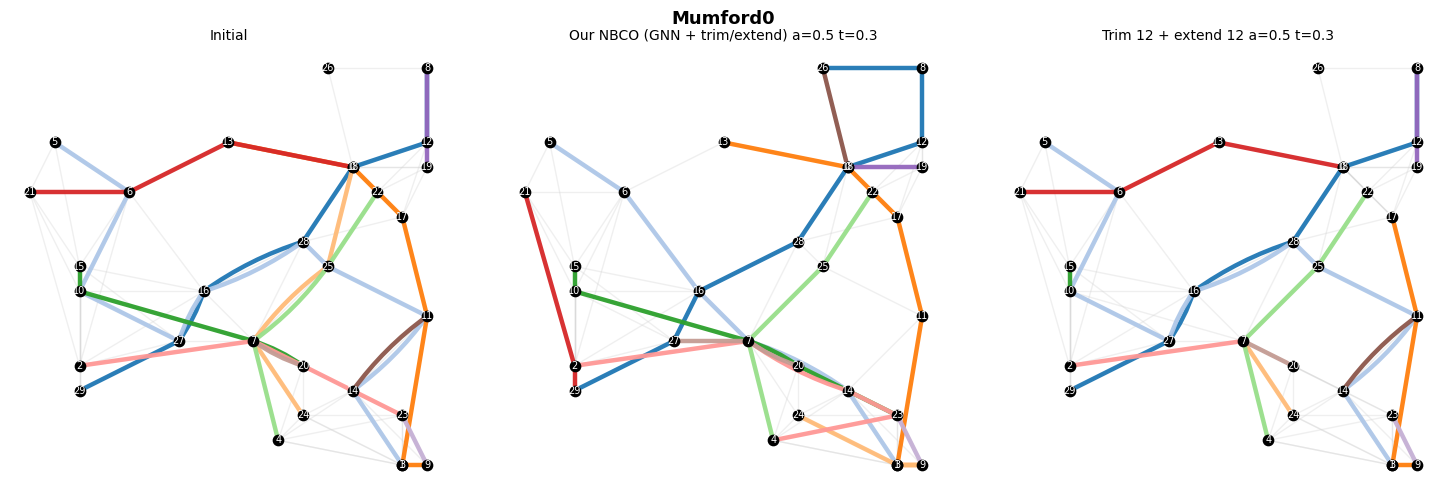

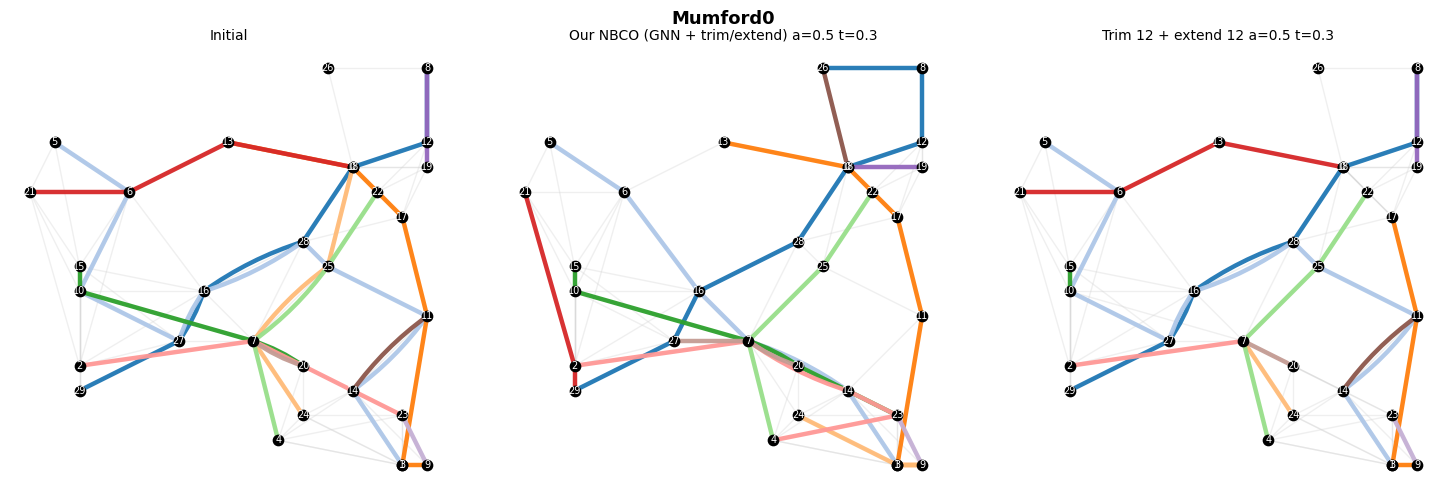

In [21]:
# Mumford0 neural-BCO variants (Our NBCO vs Trim 12 + extend 12, alpha=0.5) --
# unified via run_experiment. The inline build_bco_cfg variant dicts, the RL-only
# probe and the bespoke 2-panel plot (~290 lines) collapse to a config-first
# m0_variants.yaml spec + run_experiment + render_report.
M0_NBCO_TABLE = ("final_mumford0_nbco_variants_alpha05_target03_iter200"
                 if SUITE.run.m0_nbco_variants else
                 "final_mumford0_nbco_variants_alpha05_target03_iter200_skipped")

if SUITE.run.m0_nbco_variants:
    from eval_lib.experiment_runner import run_experiment, load_experiment_spec
    from eval_lib.experiment_report import render_report

    _m0_result = run_experiment(load_experiment_spec("m0_variants_smoke" if SUITE.smoke else "m0_variants"))
    _m0_report = render_report(_m0_result)
    display(_m0_report.table)
    save_paper_table(_m0_result.table.round(4), M0_NBCO_TABLE)
    for _fig in _m0_report.figures.values():
        display(_fig)
else:
    print("Mumford0 NBCO variants skipped (RUN_M0_NBCO_VARIANTS=False)")


## E2 - Pareto fronts on RTT x WMC (Mumford0, covered_dup tier)

Both panels run on **Mumford0** from the **covered_dup** init tier (removable
redundancy), optimizing `alpha*RTT + (1-alpha)*WMC + adj(|.-target|)` with
`use_weighted_connectivity=True`. `alpha` = `route_time_weight` (so alpha=1 ->
pure RTT, alpha=0 -> pure WMC).

- **Fig 1 (our model):** RTT x WMC Pareto front of `GNN + trim/extend`, swept
  over `alpha` x `adj_target` (one curve per target).
- **Fig 2 (4-model comparison):** `{GNN, RPC} x {trim/extend, type2}`, alpha-
  swept at a fixed `adj_target=ADJ_TARGET` -> shows the trim/extend
  bee's contribution to the RTT x WMC front.

In [22]:
# === E2 -- Pareto fronts on RTT x WMC (Mumford1, realistic init tier) ===
E2_CITY = "Mumford1" if not SUITE.smoke else "Mandl"
E2_ALPHA_GRID = [round(0.25 * i, 2) for i in range(5)] if not SUITE.smoke else [0.0, 0.5, 1.0]
_E2_TARGET_GRID_FULL = [round(0.2 * i, 2) for i in range(1, 6)] if not SUITE.smoke else [0.2, 0.6]
E2_TARGET_GRID = _E2_TARGET_GRID_FULL if SUITE.run.e2_our_pareto else []
E2_FIX_TARGET = min(_E2_TARGET_GRID_FULL, key=lambda _t: abs(_t - 0.2))  # alpha-slice target
E2_FIX_ALPHA = min(E2_ALPHA_GRID, key=lambda _a: abs(_a - 0.5))    # target-slice alpha
E2_FIXED_TARGET = E2_FIX_TARGET
E2_ADJ_OBJECTIVE = "target"
E2_DEFAULT_ADJ_WEIGHT = float(ADJ_WEIGHT)
E2_FIG2_ADJ_WEIGHT = 0.0
print("E2 grid:", {"city": E2_CITY, "alpha": E2_ALPHA_GRID,
                   "adj_target": E2_TARGET_GRID, "fixed_target": E2_FIXED_TARGET,
                   "iters": E2_BCO_ITERATIONS,
                   "adj_objective": E2_ADJ_OBJECTIVE,
                   "run_our_pareto": SUITE.run.e2_our_pareto,
                   "run_5model": SUITE.run.e2_5model})


E2 grid: {'city': 'Mandl', 'alpha': [0.0, 0.5, 1.0], 'adj_target': [0.2, 0.6], 'fixed_target': 0.2, 'iters': 200, 'adj_objective': 'target', 'run_our_pareto': True, 'run_5model': True}


100%|██████████| 1/1 [00:27<00:00, 27.26s/it]

,15.000,1.394,31.815,1378.000,20.237,40.677,30.476,8.610,0.000,0.000,32.429,30.849,27.364,2.000


,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,1378.0,30.849,31.815,0.203,22.222,1.394,Our NBCO,0.5,0.2,1


[paper] table (1 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e2_our_pareto_Mandl_smoke_mumford1_5model.csv


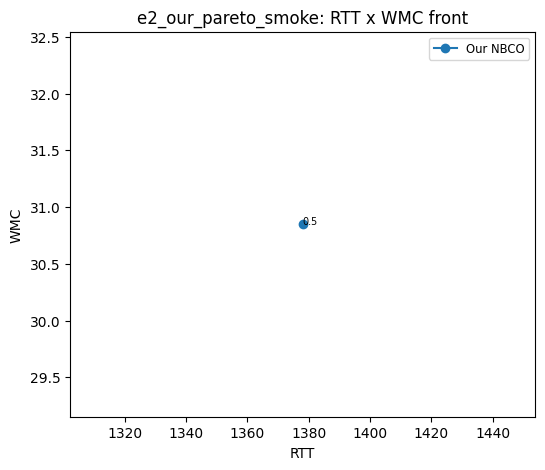

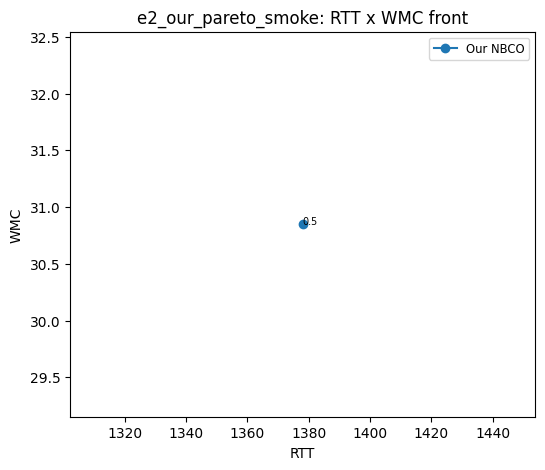

In [23]:
# E2 Our-NBCO Pareto sweep (alpha x adj_target) on Mumford1 -- unified via
# run_experiment (2D sweep). The ~210-line _e2_ctx / _run_rttwmc / _plot_fronts
# helpers + the inline our-pareto loop collapse to the config-first
# e2_our_pareto.yaml spec.
_sfx = ("_smoke" if SUITE.smoke else "") + SUITE.e2.table_suffix

if SUITE.run.e2_our_pareto:
    from eval_lib.experiment_runner import run_experiment, load_experiment_spec
    from eval_lib.experiment_report import render_report

    _e2p_result = run_experiment(load_experiment_spec("e2_our_pareto_smoke" if SUITE.smoke else "e2_our_pareto"))
    _e2p_report = render_report(_e2p_result)
    display(_e2p_report.table)
    save_paper_table(_e2p_result.table.round(4), f"final_e2_our_pareto_{E2_CITY}{_sfx}")
    for _fig in _e2p_report.figures.values():
        display(_fig)
else:
    print(f"[E2] {E2_CITY}: our-model Pareto (alpha x target) sweep skipped (RUN_E2_OUR_PARETO=False)")


100%|██████████| 1/1 [00:23<00:00, 23.34s/it]


,15.000,1.347,31.090,1322.000,19.466,48.017,26.061,6.456,0.000,0.000,31.714,30.369,23.451,2.000


100%|██████████| 1/1 [00:11<00:00, 11.56s/it]


,15.000,1.386,30.566,1384.000,21.487,43.489,28.121,6.903,0.000,0.000,30.914,29.668,11.736,2.000


100%|██████████| 1/1 [00:21<00:00, 21.89s/it]


...

,15.000,2.044,28.986,1410.000,20.714,44.370,27.702,7.214,69.000,0.000,29.536,29.302,11.298,2.000


100%|██████████| 1/1 [00:14<00:00, 14.98s/it]

,15.000,2.131,30.240,1306.000,19.496,40.671,27.210,12.623,137.000,0.000,30.574,31.535,15.235,2.000


,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,1322.0,30.369,31.090,0.356,16.547,1.347,GNN + trim/extend,0.5,0.2,1
1,1384.0,29.668,30.566,0.034,20.979,1.386,RPC + trim/extend,0.5,0.2,1
2,1298.0,30.565,31.182,0.257,22.302,1.331,GNN + type2,0.5,0.2,1
3,1410.0,29.302,28.986,0.256,28.378,2.044,RPC + type2,0.5,0.2,1
4,1306.0,31.535,30.240,0.013,18.519,2.131,trim 12 + extend 12,0.5,0.2,1


[paper] table (5 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e2_5model_Mandl_smoke_mumford1_5model.csv


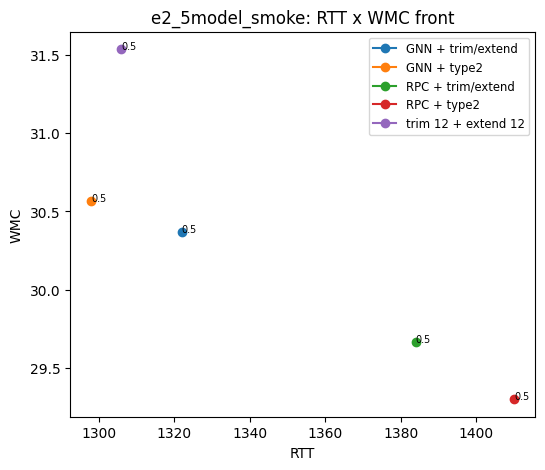

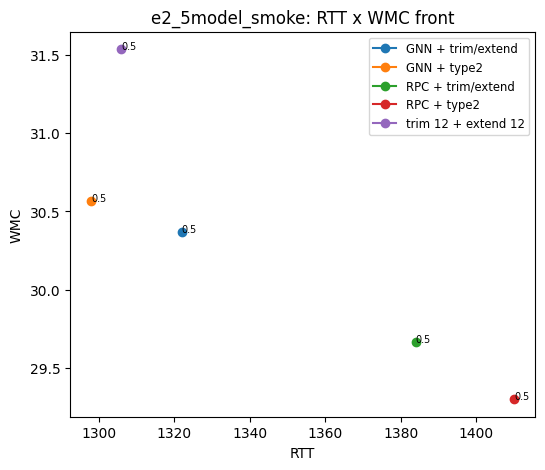

In [24]:
# E2 Fig-2: 5-model RTT x WMC comparison (GNN/RPC x trim-extend/type2 +
# trim12+extend12) on Mumford1, alpha-swept with adjustment OFF -- unified via
# run_experiment. The inline E2_MODEL_SPECS loop, _run_rttwmc config builders and
# _plot_fronts (~70 lines) become the config-first e2_5model.yaml spec.
_e2_abl_table = f"final_e2_5model_{E2_CITY}{_sfx}"
if SUITE.run.e2_5model:
    from eval_lib.experiment_runner import run_experiment, load_experiment_spec
    from eval_lib.experiment_report import render_report

    _e2_result = run_experiment(load_experiment_spec("e2_5model_smoke" if SUITE.smoke else "e2_5model"))
    _e2_report = render_report(_e2_result)
    display(_e2_report.table)
    save_paper_table(_e2_result.table.round(4), _e2_abl_table)
    for _fig in _e2_report.figures.values():
        display(_fig)
    E2_ABL_DF = _e2_result.table
else:
    print(f"[E2] {E2_CITY}: 5-model alpha sweep skipped (RUN_E2_5MODEL=False)")
    E2_ABL_DF = pd.DataFrame()


### E2 Route Visualisation

Draw selected `alpha x adj_target` route sets from the E2 our-model sweep. The first grid shows the route sets directly; the second grid highlights changes against the LC initial network.

In [25]:
# Visualise E2 our-model routes (selected alpha x target) -- unified via the
# atomic viz.plot_routes_grid. The old ~155-line cell (_draw_e2_route_grid,
# _e2_metric_subtitle, selection helpers) collapses to plain + diff grids.
import torch
from eval_lib.results_io import ARTIFACTS_DIR
from eval_lib import as_route_tensor
from eval_lib import viz

if SUITE.run.e2_route_viz:
    _e2vsfx = ("_smoke" if SUITE.smoke else "") + SUITE.e2.table_suffix
    _e2ptf = ARTIFACTS_DIR / "paper_results" / f"final_e2_our_pareto_{E2_CITY}{_e2vsfx}_routes.pt"
    if not _e2ptf.exists():
        print(f"[E2 route viz] skipped: no dump {_e2ptf.name} (run the E2 our-pareto cell first)")
    else:
        _e2dump = torch.load(_e2ptf, weights_only=False)
        _e2routes = {k: as_route_tensor(v) for k, v in _e2dump["routes"].items()}
        _e2ref = next((m for m in _e2routes if "Initial" in m), list(_e2routes)[0])
        display(viz.plot_routes_grid(_e2routes, _e2dump["coords"], _e2dump["street_adj"],
                                     title=f"E2 {E2_CITY}: our-model routes"))
        display(viz.plot_routes_grid(_e2routes, _e2dump["coords"], _e2dump["street_adj"],
                                     diff_against=_e2ref, title=f"E2 {E2_CITY}: diff vs {_e2ref}"))
else:
    print("E2 route viz skipped (RUN_E2_ROUTE_VIZ=False)")


E2 route viz skipped (RUN_E2_ROUTE_VIZ=False)


## E1 narrow -- neural BCO vs Our NBCO alpha sweep

Runs only two methods on every benchmark city (`Mandl`, `Mumford0`, `Mumford1`, `Mumford2`, `Mumford3`):
`neural BCO` and `Our NBCO (GNN rebuild + trim/extend)`. For each method we run
`alpha in {0, 0.5, 1}` with `adjustment_degree_target=0.5` and 100 BCO iterations.

All SA / GA / HH / heuristic BCO / NSGA-II / trim-only branches are disabled here. Tables are saved as
`paper_results/final_main_unified_<city><E1U_TABLE_SUFFIX>.csv` and a combined table as
`final_main_unified_comparison<E1U_TABLE_SUFFIX>.csv`.


=== Mandl E1 narrow: neural BCO + Our NBCO, alphas=[0.0, 0.5, 1.0], target=0.3, iter=200 ===


100%|██████████| 1/1 [00:01<00:00,  1.02s/it]


,6.000,0.576,13.863,136.000,56.969,28.388,14.258,0.385,0.000,0.000,19.800,15.374,1.056,2.000


100%|██████████| 1/1 [00:02<00:00,  2.16s/it]

,6.000,0.612,15.193,146.000,56.647,38.471,4.560,0.321,0.000,0.000,19.867,16.068,2.201,2.000


,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,136.0,15.374,13.863,0.305,0.0,0.576,neural BCO,0.5,0.3,1
1,146.0,16.068,15.193,0.306,0.0,0.612,Our NBCO (GNN rebuild + trim/extend),0.5,0.3,1


[paper] table (2 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_main_unified_Mandl_smoke_nbco_only_target03_iter200.csv


,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,136.0,15.374,13.863,0.305,0.0,0.576,neural BCO,0.5,0.3,1
1,146.0,16.068,15.193,0.306,0.0,0.612,Our NBCO (GNN rebuild + trim/extend),0.5,0.3,1


[paper] table (2 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_main_unified_comparison_smoke_nbco_only_target03_iter200.csv


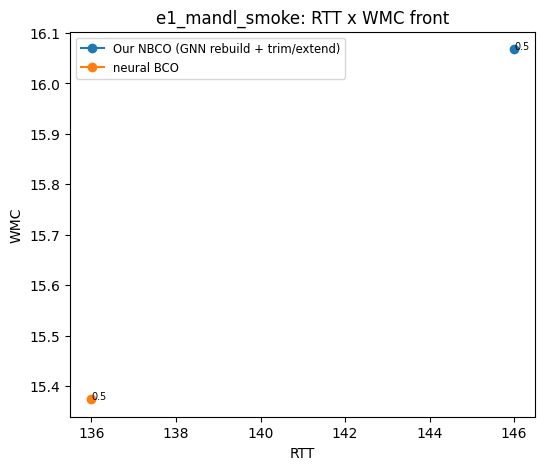

In [26]:
# E1 narrow: neural BCO vs Our NBCO alpha sweep -- unified via run_experiment.
# The per-city neural-BCO / Our-NBCO comparison over the alpha grid (formerly the
# ~190-line run_city_e1u_nbco_our_alpha with inline config builders, baseline
# caching and CSV streaming) is now a config-first call: each e1_<city>.yaml spec
# lists the data source, the two methods (captured bee-mix configs) and the alpha
# sweep. run_experiment iterates methods x alpha; render_report builds the table.
from eval_lib.experiment_runner import run_experiment, load_experiment_spec
from eval_lib.experiment_report import render_report

_e1u_sfx = ("_smoke" if SUITE.smoke else "") + SUITE.e1.table_suffix
_u_all_rows = []
for _city in SUITE.e1.cities:
    print(f"=== {_city} E1 narrow: neural BCO + Our NBCO, alphas={SUITE.e1.alpha_grid}, "
          f"target={SUITE.e1.adj_target}, iter={SUITE.e1.bco_iterations} ===", flush=True)
    _result = run_experiment(load_experiment_spec(f"e1_{_city.lower()}" + ("_smoke" if SUITE.smoke else "")))
    _report = render_report(_result)
    display(_report.table)
    save_paper_table(_result.table.round(3), f"final_main_unified_{_city}{_e1u_sfx}")
    _u_all_rows += _result.table.to_dict("records")

unified_df = pd.DataFrame(_u_all_rows).round(3)
if not unified_df.empty:
    display(unified_df)
    save_paper_table(unified_df, "final_main_unified_comparison" + _e1u_sfx)
else:
    print("E1 narrow skipped: E1U_CITIES is empty.")


### Route visualisation (unified run: RTT + WMC + adj for all methods)

Drawn from the **unified** dumps (`final_main_unified_<city>`). Layout: OD demand -> init -> methods (plain & diff vs init), plus a focused 1x4 (our routes / init / neural-BCO diff / our-NBCO diff).

In [27]:
# Route-set visualisation from saved E1 route dumps -- unified via the atomic
# viz.plot_routes_grid (plain panels + a diff-vs-Initial grid, one style). The
# old ~130-line cell (manual grids, overlap ribbons, focused 1x4, metric
# subtitles) collapses to two atomic calls.
import torch
from eval_lib.results_io import ARTIFACTS_DIR
from eval_lib import as_route_tensor
from eval_lib import viz

VIZ_CITY = "Mumford0"
VIZ_NCOL = 3
_prdir = ARTIFACTS_DIR / "paper_results"
_vsfx = ("_smoke" if SUITE.smoke else "") + globals().get("E1U_TABLE_SUFFIX", "")
_ptf = _prdir / f"final_main_unified_{VIZ_CITY}{_vsfx}_routes.pt"
if not _ptf.exists():
    print(f"[route viz] skipped: no dump {_ptf.name} (run E1u for {VIZ_CITY} first)")
else:
    _dump = torch.load(_ptf, weights_only=False)
    _routes = {k: as_route_tensor(v) for k, v in _dump["routes"].items()}
    _coords, _adj = _dump["coords"], _dump["street_adj"]
    _ref = next((m for m in _routes if "Initial" in m), list(_routes)[0])
    display(viz.plot_routes_grid(_routes, _coords, _adj, ncols=VIZ_NCOL,
                                 title=f"{VIZ_CITY}: route sets"))
    display(viz.plot_routes_grid(_routes, _coords, _adj, ncols=VIZ_NCOL,
                                 diff_against=_ref, title=f"{VIZ_CITY}: diff vs {_ref}"))


[route viz] skipped: no dump final_main_unified_Mumford0_smoke_nbco_only_target03_iter200_routes.pt (run E1u for Mumford0 first)


## MACSA Table B -- paper routes + Our NBCO alpha sweep

This section replaces the old generic MACSA probe with the exact Mandl-8 Table-B workflow used for the paper figures. It reads the fixed route sets from `datasets/MACSA_data/mandl_8/routes_*.txt`, scores them with the same E1-style metric plumbing, then runs Our NBCO from the original network with `adjustment_degree_target = adj(MACSA, original)`.

Outputs:
- `final_macsa_mandl8_alpha_sweep_iter100.*`: Our NBCO alpha sweep, `alpha=0.0..1.0` step `0.1`, 100 BCO iterations per run.
- `final_macsa_mandl8_tableb.*`: Table-B paper methods plus the best Our NBCO sweep solution that beats MACSA on both RTT and WMC. The old cap-mode row is intentionally not included.


In [28]:
# MACSA Table-B case study: thick helpers now live in experiments/macsa.py
# (one-off paper experiment kept out of the reusable library). Configure the
# runtime values, then import the helpers + scenario constants by their bare
# names so the orchestration cells below read unchanged.
import sys
from pathlib import Path

_MACSA_NOTEBOOK_DIR = Path("examples/route_generator").resolve()
if str(_MACSA_NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(_MACSA_NOTEBOOK_DIR))

from experiments import macsa

_cfg = macsa.configure(
    smoke=SUITE.smoke,
    our_model_path=OUR_MODEL_PATH if "OUR_MODEL_PATH" in dir() else None,
    seeds=SUITE.seeds if "SEEDS" in dir() else [0],
)
from experiments.macsa import *  # noqa: F401,F403  (helpers + MACSA_* constants)

print("MACSA Table-B config:", _cfg)


MACSA Table-B config: {'scenario_dir': 'D:\\PythonProjects\\connectpt\\datasets\\MACSA_data\\mandl_8', 'alpha_grid': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 'bco_iterations': 1, 'bco_bees': 10, 'seed': 0, 'force_cpu': False, 'our_model': 'improvement_lc_rttconn_adj_w10_t02_finetune100.pt'}


In [29]:
# Score the fixed Mandl-8 Table-B routes from the MACSA paper.
if not SUITE.run.macsa:
    MACSA_TABLEB_DF = pd.DataFrame()
    MACSA_TABLEB_ROUTES = {}
    print("MACSA Table-B skipped (RUN_MACSA_EXPERIMENTS=False).")
else:
    MACSA_TENSORS = load_macsa_tensors(MACSA_SCENARIO_DIR)
    MACSA_COORDS = MACSA_TENSORS["node_locs"]
    MACSA_STREET_ADJ = MACSA_TENSORS["street_adj"]
    MACSA_DEMAND = MACSA_TENSORS["demand"]
    MACSA_RAW_ROUTES = {
        MACSA_METHOD_TITLE[key]: _macsa_read_routes_0indexed(MACSA_SCENARIO_DIR / f"routes_{key}.txt")
        for key in MACSA_METHOD_ORDER
    }
    MACSA_SPEC = _macsa_build_spec(MACSA_RAW_ROUTES, int(MACSA_COORDS.shape[0]))
    MACSA_TABLEB_ROUTES = {
        method: _macsa_pad_routes(routes, MACSA_SPEC["n_routes"], MACSA_SPEC["max_route_len"])
        for method, routes in MACSA_RAW_ROUTES.items()
    }
    MACSA_SEED_ROUTES = MACSA_TABLEB_ROUTES[MACSA_REF_METHOD]
    MACSA_ADJ_TARGET_FROM_MACSA = float(adj_vs_init(MACSA_TABLEB_ROUTES["MACSA"], MACSA_SEED_ROUTES))

    MACSA_TABLEB_ROWS = []
    for method in MACSA_TABLEB_ROUTES:
        row, scored = _macsa_score_routes(
            method, "macsa_table_b", MACSA_TABLEB_ROUTES[method],
            seed_routes=MACSA_SEED_ROUTES, tensors=MACSA_TENSORS, spec=MACSA_SPEC,
            alpha=MACSA_TABLEB_EVAL_ALPHA,
            adj_target=MACSA_TABLEB_EVAL_ADJ_TARGET,
            adj_objective=MACSA_TABLEB_EVAL_ADJ_OBJECTIVE)
        row.update(alpha=np.nan, run_alpha=np.nan, n_iterations=np.nan,
                   macsa_adj_target=MACSA_ADJ_TARGET_FROM_MACSA)
        MACSA_TABLEB_ROWS.append(row)
        MACSA_TABLEB_ROUTES[method] = scored
        print(f"  {method:20} ATT={row['ATT']:.2f} RTT={row['RTT']:.0f} "
              f"WMC={row['WMC']:.2f} adj={row['adj_vs_seed']:.3f} cost={row['cost']:.3f}")

    MACSA_TABLEB_DF = pd.DataFrame(MACSA_TABLEB_ROWS).round(6)
    save_paper_table(MACSA_TABLEB_DF, MACSA_ARTICLE_STEM)
    save_paper_routes(MACSA_ARTICLE_STEM, MACSA_TABLEB_ROUTES,
                      MACSA_COORDS, MACSA_STREET_ADJ,
                      meta={"scenario": MACSA_SCENARIO_NAME,
                            "ref_method": MACSA_REF_METHOD,
                            "eval_alpha": MACSA_TABLEB_EVAL_ALPHA,
                            "eval_adj_target": MACSA_TABLEB_EVAL_ADJ_TARGET,
                            "macsa_adj_target": MACSA_ADJ_TARGET_FROM_MACSA})
    print(f"MACSA adj target from Table-B MACSA vs original: {MACSA_ADJ_TARGET_FROM_MACSA:.6f}")
    display(MACSA_TABLEB_DF)


NameError: name 'load_macsa_tensors' is not defined

In [ ]:
# Run Our NBCO alpha sweep: alpha=0.0..1.0 step 0.1, exactly 100 BCO iterations each.
if not SUITE.run.macsa or MACSA_TABLEB_DF.empty:
    MACSA_SWEEP_DF = pd.DataFrame()
    MACSA_SWEEP_ROUTES = {}
    print("MACSA alpha sweep skipped: no scored Table-B routes.")
else:
    sweep_csv = PAPER_DIR / f"{MACSA_SWEEP_STEM}.csv"
    sweep_routes_path = PAPER_DIR / f"{MACSA_SWEEP_STEM}_routes.pt"
    cached_routes = {}
    cached_duration = {}
    if sweep_routes_path.exists() and sweep_csv.exists() and not MACSA_SWEEP_FORCE_RERUN:
        try:
            payload = torch.load(sweep_routes_path, map_location="cpu", weights_only=False)
            meta = payload.get("meta", {})
            if int(meta.get("bco_iterations", -1)) == int(MACSA_SWEEP_BCO_ITERATIONS):
                cached_routes = {k: as_route_tensor(v) for k, v in payload.get("routes", {}).items()}
                cache_df = pd.read_csv(sweep_csv)
                if "method" in cache_df:
                    cached_duration = dict(zip(cache_df["method"].astype(str),
                                               cache_df.get("duration_s", pd.Series(dtype=float))))
                print(f"[macsa sweep] loaded cache: {sweep_routes_path.name}")
            else:
                print("[macsa sweep] cache ignored: iteration count mismatch")
        except Exception as exc:
            print(f"[macsa sweep] cache ignored: {exc}")

    MACSA_SWEEP_ROWS = []
    MACSA_SWEEP_ROUTES = {}

    def _macsa_save_sweep_progress():
        df = pd.DataFrame(MACSA_SWEEP_ROWS).sort_values("alpha").round(6)
        save_paper_table(df, MACSA_SWEEP_STEM)
        save_paper_routes(MACSA_SWEEP_STEM, MACSA_SWEEP_ROUTES,
                          MACSA_COORDS, MACSA_STREET_ADJ,
                          meta={"scenario": MACSA_SCENARIO_NAME,
                                "ref_method": MACSA_REF_METHOD,
                                "alpha_grid": MACSA_ALPHA_GRID,
                                "bco_iterations": MACSA_SWEEP_BCO_ITERATIONS,
                                "bco_bees": MACSA_SWEEP_BEES,
                                "seed": MACSA_SWEEP_SEED,
                                "adj_target": MACSA_ADJ_TARGET_FROM_MACSA,
                                "adj_objective": "target"})
        return df

    for alpha in tqdm(MACSA_ALPHA_GRID, desc="MACSA Our NBCO alpha sweep"):
        label = _macsa_alpha_label(alpha)
        if label in cached_routes and not MACSA_SWEEP_FORCE_RERUN:
            print(f"  [cache] {label}")
            routes = _macsa_pad_routes(cached_routes[label], MACSA_SPEC["n_routes"], MACSA_SPEC["max_route_len"])
            duration = float(cached_duration.get(label, np.nan)) if label in cached_duration else np.nan
            source = "our_nbco_alpha_sweep_cached"
        else:
            print(f"  [run] {label}: alpha={alpha:.1f}, iters={MACSA_SWEEP_BCO_ITERATIONS}", flush=True)
            routes, duration = _macsa_run_our_nbco(
                MACSA_SEED_ROUTES, tensors=MACSA_TENSORS, spec=MACSA_SPEC,
                alpha=float(alpha), adj_target=MACSA_ADJ_TARGET_FROM_MACSA,
                adj_objective="target", n_iterations=MACSA_SWEEP_BCO_ITERATIONS,
                n_bees=MACSA_SWEEP_BEES, seed=MACSA_SWEEP_SEED,
                force_cpu=MACSA_FORCE_CPU)
            source = "our_nbco_alpha_sweep"
        row, scored = _macsa_score_routes(
            label, source, routes, seed_routes=MACSA_SEED_ROUTES,
            tensors=MACSA_TENSORS, spec=MACSA_SPEC,
            alpha=float(alpha), adj_target=MACSA_ADJ_TARGET_FROM_MACSA,
            adj_objective="target")
        row.update(duration_s=duration, alpha=float(alpha), run_alpha=float(alpha),
                   n_iterations=int(MACSA_SWEEP_BCO_ITERATIONS),
                   macsa_adj_target=MACSA_ADJ_TARGET_FROM_MACSA,
                   beats_macsa_rtt_wmc=bool(
                       (float(row["RTT"]) < float(MACSA_TABLEB_DF.loc[MACSA_TABLEB_DF["method"] == "MACSA", "RTT"].iloc[0])) and
                       (float(row["WMC"]) < float(MACSA_TABLEB_DF.loc[MACSA_TABLEB_DF["method"] == "MACSA", "WMC"].iloc[0]))))
        MACSA_SWEEP_ROWS = _macsa_upsert_row(MACSA_SWEEP_ROWS, row)
        MACSA_SWEEP_ROUTES[label] = scored
        MACSA_SWEEP_DF = _macsa_save_sweep_progress()
        print(f"    -> RTT={row['RTT']:.0f} WMC={row['WMC']:.2f} "
              f"ATT={row['ATT']:.2f} adj={row['adj_vs_seed']:.3f} cost={row['cost']:.3f} "
              f"duration={duration:.1f}s", flush=True)

    MACSA_SWEEP_DF = pd.DataFrame(MACSA_SWEEP_ROWS).sort_values("alpha").round(6)
    display(MACSA_SWEEP_DF)


In [ ]:
# Pick the best Our NBCO sweep solution that beats MACSA on both RTT and WMC,
# then build the comparison table: all Table-B methods + that single Our solution.
if not SUITE.run.macsa or MACSA_SWEEP_DF.empty:
    MACSA_COMPARISON_DF = pd.DataFrame()
    MACSA_COMPARISON_ROUTES = {}
    print("MACSA comparison skipped: no sweep rows.")
else:
    macsa_ref_row = MACSA_TABLEB_DF[MACSA_TABLEB_DF["method"] == "MACSA"].iloc[0]
    MACSA_BEST_SWEEP_ROW = _macsa_select_best_sweep_row(MACSA_SWEEP_DF, macsa_ref_row)
    MACSA_BEST_SWEEP_LABEL = str(MACSA_BEST_SWEEP_ROW["method"])
    MACSA_BEST_ALPHA = float(MACSA_BEST_SWEEP_ROW["alpha"])
    MACSA_BEST_BEATS_MACSA = bool(MACSA_BEST_SWEEP_ROW["beats_macsa_rtt_wmc"])
    MACSA_BEST_COMPARE_LABEL = f"Our NBCO best (alpha={MACSA_BEST_ALPHA:.1f}, iter={MACSA_SWEEP_BCO_ITERATIONS})"

    best_compare_row, best_compare_routes = _macsa_score_routes(
        MACSA_BEST_COMPARE_LABEL, "our_nbco_alpha_sweep_best",
        MACSA_SWEEP_ROUTES[MACSA_BEST_SWEEP_LABEL],
        seed_routes=MACSA_SEED_ROUTES, tensors=MACSA_TENSORS, spec=MACSA_SPEC,
        alpha=MACSA_TABLEB_EVAL_ALPHA,
        adj_target=MACSA_TABLEB_EVAL_ADJ_TARGET,
        adj_objective=MACSA_TABLEB_EVAL_ADJ_OBJECTIVE)
    best_compare_row.update(alpha=MACSA_BEST_ALPHA,
                            run_alpha=MACSA_BEST_ALPHA,
                            n_iterations=int(MACSA_SWEEP_BCO_ITERATIONS),
                            macsa_adj_target=MACSA_ADJ_TARGET_FROM_MACSA,
                            beats_macsa_rtt_wmc=MACSA_BEST_BEATS_MACSA,
                            selected_from=MACSA_BEST_SWEEP_LABEL,
                            selection_rule="min RTT/MACSA_RTT + WMC/MACSA_WMC among rows beating MACSA on both")

    MACSA_COMPARISON_ROUTES = dict(MACSA_TABLEB_ROUTES)
    MACSA_COMPARISON_ROUTES[MACSA_BEST_COMPARE_LABEL] = best_compare_routes
    MACSA_COMPARISON_DF = pd.concat(
        [MACSA_TABLEB_DF, pd.DataFrame([best_compare_row])], ignore_index=True, sort=False).round(6)
    save_paper_table(MACSA_COMPARISON_DF, MACSA_COMPARISON_STEM)
    save_paper_routes(MACSA_COMPARISON_STEM, MACSA_COMPARISON_ROUTES,
                      MACSA_COORDS, MACSA_STREET_ADJ,
                      meta={"scenario": MACSA_SCENARIO_NAME,
                            "ref_method": MACSA_REF_METHOD,
                            "article_methods": [MACSA_METHOD_TITLE[k] for k in MACSA_METHOD_ORDER],
                            "best_our_method": MACSA_BEST_COMPARE_LABEL,
                            "best_sweep_method": MACSA_BEST_SWEEP_LABEL,
                            "best_beats_macsa_rtt_wmc": MACSA_BEST_BEATS_MACSA,
                            "bco_iterations": MACSA_SWEEP_BCO_ITERATIONS,
                            "sweep_stem": MACSA_SWEEP_STEM,
                            "cap_mode_included": False})
    print("Best Our NBCO sweep solution:", {
        "method": MACSA_BEST_SWEEP_LABEL,
        "alpha": MACSA_BEST_ALPHA,
        "beats_macsa_rtt_wmc": MACSA_BEST_BEATS_MACSA,
        "RTT": float(MACSA_BEST_SWEEP_ROW["RTT"]),
        "WMC": float(MACSA_BEST_SWEEP_ROW["WMC"]),
        "ATT": float(MACSA_BEST_SWEEP_ROW["ATT"]),
        "adj": float(MACSA_BEST_SWEEP_ROW["adj_vs_seed"]),
    })
    display(MACSA_COMPARISON_DF)


In [ ]:
# Visualize only Our NBCO alpha-sweep solutions.
if not SUITE.run.macsa or MACSA_SWEEP_DF.empty:
    print("MACSA our-only visualization skipped: no sweep rows.")
else:
    sweep_order = [str(row["method"]) for _, row in MACSA_SWEEP_DF.sort_values("alpha").iterrows()]
    sweep_routes_ordered = {name: MACSA_SWEEP_ROUTES[name] for name in sweep_order}
    sweep_rows_by_method = {str(row["method"]): row.to_dict()
                            for _, row in MACSA_SWEEP_DF.iterrows()}

    fig = _macsa_draw_grid(
        routes=sweep_routes_ordered, rows_by_method=sweep_rows_by_method,
        coords=MACSA_COORDS, street_adj=MACSA_STREET_ADJ, demand=MACSA_DEMAND,
        diff=False, ref_key=None, ref_routes=MACSA_SEED_ROUTES,
        include_demand=True, include_ref=False, ncol=4,
        title="Mandl-8 MACSA: Our NBCO alpha sweep, plain route sets")
    MACSA_SWEEP_PLAIN_PATH = _macsa_save_fig(fig, MACSA_SWEEP_STEM, "viz_plain")

    fig = _macsa_draw_grid(
        routes=sweep_routes_ordered, rows_by_method=sweep_rows_by_method,
        coords=MACSA_COORDS, street_adj=MACSA_STREET_ADJ, demand=MACSA_DEMAND,
        diff=True, ref_key=MACSA_REF_METHOD, ref_routes=MACSA_SEED_ROUTES,
        include_demand=True, include_ref=False, ncol=4,
        title="Mandl-8 MACSA: Our NBCO alpha sweep, diff vs original")
    MACSA_SWEEP_DIFF_PATH = _macsa_save_fig(fig, MACSA_SWEEP_STEM, "viz_diff")
    _macsa_display_image(MACSA_SWEEP_PLAIN_PATH)
    _macsa_display_image(MACSA_SWEEP_DIFF_PATH)


In [ ]:
# Visualize all paper Table-B solutions plus the selected best Our NBCO solution.
if not SUITE.run.macsa or MACSA_COMPARISON_DF.empty:
    print("MACSA comparison visualization skipped: no comparison table.")
else:
    comparison_rows_by_method = {str(row["method"]): row.to_dict()
                                 for _, row in MACSA_COMPARISON_DF.iterrows()}
    fig = _macsa_draw_grid(
        routes=MACSA_COMPARISON_ROUTES, rows_by_method=comparison_rows_by_method,
        coords=MACSA_COORDS, street_adj=MACSA_STREET_ADJ, demand=MACSA_DEMAND,
        diff=False, ref_key=MACSA_REF_METHOD, ref_routes=MACSA_SEED_ROUTES,
        include_demand=True, include_ref=True, ncol=5,
        title="Mandl-8 MACSA Table B: paper methods + best Our NBCO")
    MACSA_COMPARISON_PLAIN_PATH = _macsa_save_fig(fig, MACSA_COMPARISON_STEM, "viz_plain")

    fig = _macsa_draw_grid(
        routes=MACSA_COMPARISON_ROUTES, rows_by_method=comparison_rows_by_method,
        coords=MACSA_COORDS, street_adj=MACSA_STREET_ADJ, demand=MACSA_DEMAND,
        diff=True, ref_key=MACSA_REF_METHOD, ref_routes=MACSA_SEED_ROUTES,
        include_demand=True, include_ref=True, ncol=5,
        title="Mandl-8 MACSA Table B: paper methods + best Our NBCO, diff vs original")
    MACSA_COMPARISON_DIFF_PATH = _macsa_save_fig(fig, MACSA_COMPARISON_STEM, "viz_diff")
    _macsa_display_image(MACSA_COMPARISON_PLAIN_PATH)
    _macsa_display_image(MACSA_COMPARISON_DIFF_PATH)
